In [1]:
# ============================================================
# Unzip HAM10000 image ZIP files
# ============================================================

import zipfile
from pathlib import Path

# Current Jupyter working directory
BASE_DIR = Path.cwd()

# ZIP files
zip_files = [
    BASE_DIR / "HAM10000_images_part_1.zip"
]

# Destination folder
extract_dir = BASE_DIR / "HAM10000_images"

extract_dir.mkdir(parents=True, exist_ok=True)

for zip_path in zip_files:

    if not zip_path.exists():
        print(f"❌ File not found: {zip_path}")
        continue

    print(f"Extracting: {zip_path.name}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print(f"✅ Completed: {zip_path.name}")

print("\n===================================")
print("✅ All ZIP files extracted")
print("📁 Location:", extract_dir)
print("===================================")

Extracting: HAM10000_images_part_1.zip
✅ Completed: HAM10000_images_part_1.zip

✅ All ZIP files extracted
📁 Location: /workspace/damodar/mahek_sheetal/HAM10000_images


In [2]:
# ============================================================
# Unzip HAM10000 image ZIP files
# ============================================================

import zipfile
from pathlib import Path

# Current Jupyter working directory
BASE_DIR = Path.cwd()

# ZIP files
zip_files = [
    BASE_DIR / "HAM10000_images_part_2.zip"
]

# Destination folder
extract_dir = BASE_DIR / "HAM10000_images"

extract_dir.mkdir(parents=True, exist_ok=True)

for zip_path in zip_files:

    if not zip_path.exists():
        print(f"❌ File not found: {zip_path}")
        continue

    print(f"Extracting: {zip_path.name}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print(f"✅ Completed: {zip_path.name}")

print("\n===================================")
print("✅ All ZIP files extracted")
print("📁 Location:", extract_dir)
print("===================================")

Extracting: HAM10000_images_part_2.zip
✅ Completed: HAM10000_images_part_2.zip

✅ All ZIP files extracted
📁 Location: /workspace/damodar/mahek_sheetal/HAM10000_images


HAM10000 DATASET
Image directory : HAM10000_images
Total images    : 10015

10 Selected Images:
01. ISIC_0028208.jpg
02. ISIC_0028944.jpg
03. ISIC_0028460.jpg
04. ISIC_0034297.jpg
05. ISIC_0029158.jpg
06. ISIC_0033127.jpg
07. ISIC_0034073.jpg
08. ISIC_0031088.jpg
09. ISIC_0032084.jpg
10. ISIC_0027221.jpg


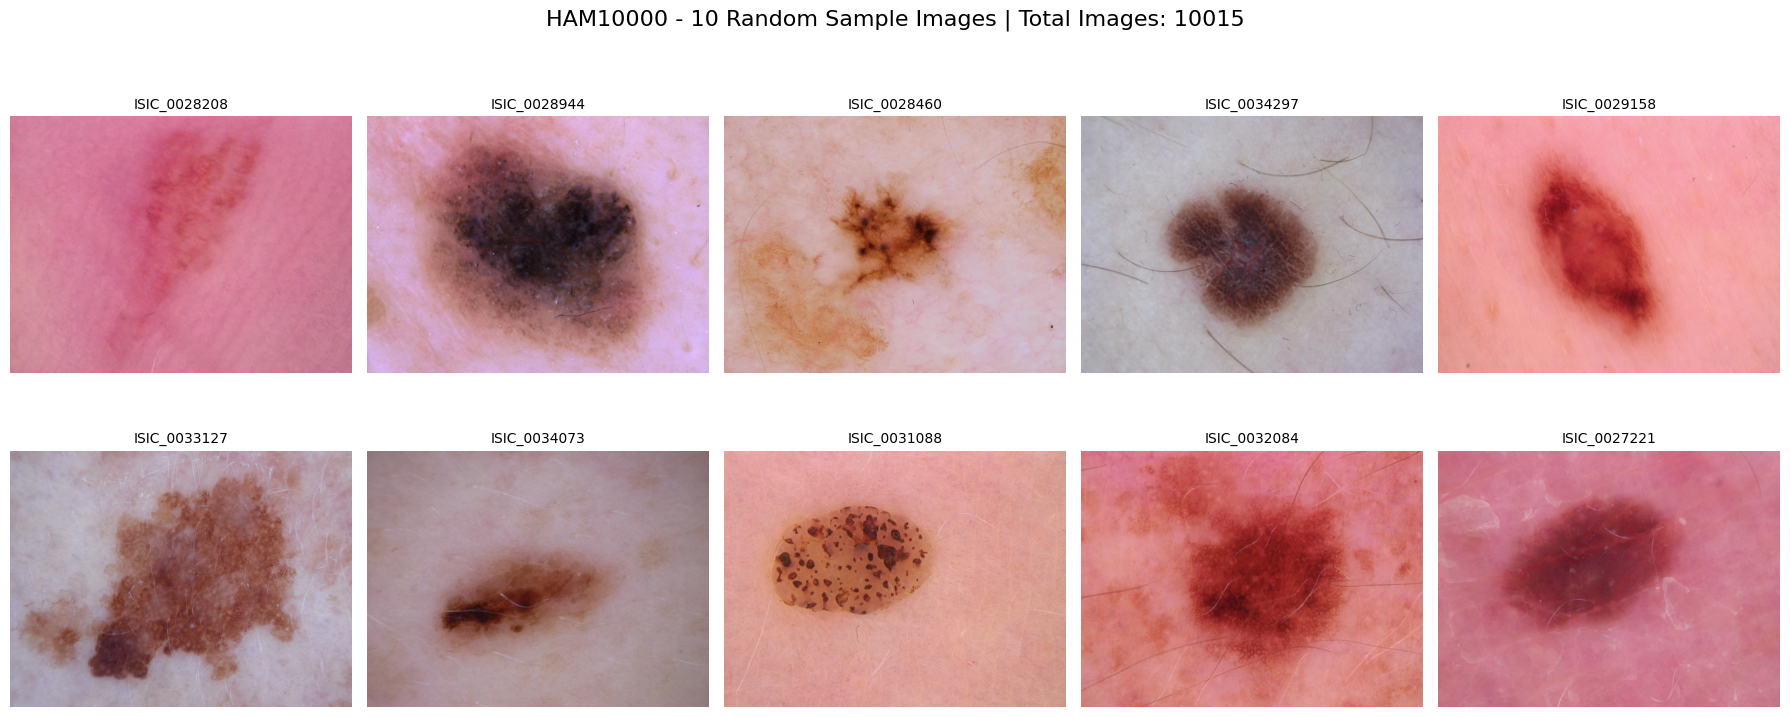

In [3]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image

# Dataset folder
IMAGE_DIR = Path("HAM10000_images")

# Read all image files
image_files = (
    list(IMAGE_DIR.rglob("*.jpg")) +
    list(IMAGE_DIR.rglob("*.jpeg")) +
    list(IMAGE_DIR.rglob("*.png"))
)

# ============================================================
# Total number of images
# ============================================================

print("=" * 50)
print("HAM10000 DATASET")
print("=" * 50)

print("Image directory :", IMAGE_DIR)
print("Total images    :", len(image_files))

# ============================================================
# Randomly select 10 images
# ============================================================

sample_images = random.sample(image_files, min(10, len(image_files)))

print("\n10 Selected Images:")
for i, img_path in enumerate(sample_images, 1):
    print(f"{i:02d}. {img_path.name}")

# ============================================================
# Display 10 images
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, img_path in zip(axes.flatten(), sample_images):
    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(img_path.stem, fontsize=10)
    ax.axis("off")

plt.suptitle(
    f"HAM10000 - 10 Random Sample Images | Total Images: {len(image_files)}",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# HAM10000 - Compare Images with Metadata CSV
# ============================================================

from pathlib import Path
import pandas as pd
from collections import Counter

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

IMAGE_DIR = Path("HAM10000_images")
CSV_PATH = Path("HAM10000_metadata.csv")

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("=" * 70)
print("HAM10000 IMAGE vs METADATA VERIFICATION")
print("=" * 70)

print("\nCSV columns:")
print(df.columns.tolist())

print("\nCSV shape:", df.shape)

# ------------------------------------------------------------
# Read all images
# ------------------------------------------------------------

image_files = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    image_files.extend(IMAGE_DIR.rglob(ext))

print("\nTotal physical image files :", len(image_files))

# filenames without extension
image_ids = [p.stem for p in image_files]

# ------------------------------------------------------------
# CSV image IDs
# ------------------------------------------------------------

if "image_id" not in df.columns:
    raise ValueError(
        "CSV does not contain an 'image_id' column.\n"
        f"Available columns: {df.columns.tolist()}"
    )

csv_ids = df["image_id"].astype(str).str.strip().tolist()

# ------------------------------------------------------------
# Basic counts
# ------------------------------------------------------------

unique_folder_ids = set(image_ids)
unique_csv_ids = set(csv_ids)

print("\n" + "-" * 70)
print("BASIC COUNTS")
print("-" * 70)

print(f"CSV rows                  : {len(df)}")
print(f"Unique image IDs in CSV   : {len(unique_csv_ids)}")
print(f"Physical image files      : {len(image_files)}")
print(f"Unique image IDs in folder: {len(unique_folder_ids)}")

# ------------------------------------------------------------
# Compare CSV vs image folder
# ------------------------------------------------------------

missing_images = sorted(unique_csv_ids - unique_folder_ids)
extra_images = sorted(unique_folder_ids - unique_csv_ids)

print("\n" + "-" * 70)
print("CSV ↔ IMAGE COMPARISON")
print("-" * 70)

print(f"Images listed in CSV but missing from folder : {len(missing_images)}")
print(f"Images in folder but not present in CSV      : {len(extra_images)}")

if missing_images:
    print("\nMissing images:")
    for img in missing_images[:30]:
        print(" ❌", img)

    if len(missing_images) > 30:
        print(f"... and {len(missing_images) - 30} more")

if extra_images:
    print("\nExtra images:")
    for img in extra_images[:30]:
        print(" ⚠️", img)

    if len(extra_images) > 30:
        print(f"... and {len(extra_images) - 30} more")

# ------------------------------------------------------------
# Duplicate physical image IDs
# ------------------------------------------------------------

folder_counts = Counter(image_ids)

duplicate_folder_ids = {
    image_id: count
    for image_id, count in folder_counts.items()
    if count > 1
}

print("\n" + "-" * 70)
print("DUPLICATE IMAGE FILE CHECK")
print("-" * 70)

print("Duplicate image IDs in folder:", len(duplicate_folder_ids))

if duplicate_folder_ids:
    for image_id, count in list(duplicate_folder_ids.items())[:30]:

        paths = [
            str(p)
            for p in image_files
            if p.stem == image_id
        ]

        print(f"\n⚠️ {image_id} appears {count} times")

        for p in paths:
            print("   ", p)

# ------------------------------------------------------------
# Duplicate IDs inside metadata
# ------------------------------------------------------------

duplicate_csv = df[df["image_id"].duplicated(keep=False)].sort_values("image_id")

print("\n" + "-" * 70)
print("DUPLICATE METADATA CHECK")
print("-" * 70)

print("Duplicate image_id rows in CSV:", len(duplicate_csv))

if len(duplicate_csv) > 0:
    print(
        duplicate_csv[
            ["image_id"] +
            (["dx"] if "dx" in duplicate_csv.columns else [])
        ].head(30).to_string(index=False)
    )

# ------------------------------------------------------------
# Find all physical paths for extra / duplicate investigation
# ------------------------------------------------------------

if extra_images:

    print("\n" + "-" * 70)
    print("PATHS OF EXTRA IMAGES")
    print("-" * 70)

    for image_id in extra_images[:20]:

        matching_paths = [
            p for p in image_files
            if p.stem == image_id
        ]

        for path in matching_paths:
            print(path)

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

if "dx" in df.columns:

    print("\n" + "-" * 70)
    print("HAM10000 CLASS DISTRIBUTION")
    print("-" * 70)

    class_names = {
        "akiec": "Actinic keratoses / Bowen's disease",
        "bcc":   "Basal cell carcinoma",
        "bkl":   "Benign keratosis-like lesions",
        "df":    "Dermatofibroma",
        "mel":   "Melanoma",
        "nv":    "Melanocytic nevi",
        "vasc":  "Vascular lesions"
    }

    counts = df["dx"].value_counts()

    for label, count in counts.items():

        full_name = class_names.get(label, label)

        print(
            f"{label:6s} : {count:5d} images | {full_name}"
        )

# ------------------------------------------------------------
# Check metadata completeness
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("MISSING VALUES IN CSV")
print("-" * 70)

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("✅ No missing metadata values.")
else:
    print(missing_values)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET STATUS")
print("=" * 70)

if (
    len(missing_images) == 0
    and len(extra_images) == 0
    and len(duplicate_folder_ids) == 0
):

    print("✅ PERFECT MATCH")
    print("Every image has corresponding metadata.")

else:

    print("⚠️ DATASET REQUIRES CLEANING")

    if missing_images:
        print(
            f"❌ {len(missing_images)} metadata records "
            "do not have corresponding images."
        )

    if extra_images:
        print(
            f"⚠️ {len(extra_images)} image IDs "
            "are not present in metadata."
        )

    if duplicate_folder_ids:
        print(
            f"⚠️ {len(duplicate_folder_ids)} image IDs "
            "exist multiple times physically."
        )

print("=" * 70)

HAM10000 IMAGE vs METADATA VERIFICATION

CSV columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

CSV shape: (10015, 7)

Total physical image files : 10015

----------------------------------------------------------------------
BASIC COUNTS
----------------------------------------------------------------------
CSV rows                  : 10015
Unique image IDs in CSV   : 10015
Physical image files      : 10015
Unique image IDs in folder: 10015

----------------------------------------------------------------------
CSV ↔ IMAGE COMPARISON
----------------------------------------------------------------------
Images listed in CSV but missing from folder : 0
Images in folder but not present in CSV      : 0

----------------------------------------------------------------------
DUPLICATE IMAGE FILE CHECK
----------------------------------------------------------------------
Duplicate image IDs in folder: 0

------------------------------------------------------

In [5]:
# ============================================================
# BLOCK 1 — ENVIRONMENT & NVIDIA H200 VERIFICATION
# HAM10000 + YOLO26-M Classification
# ============================================================

import os
import sys
import platform
from pathlib import Path

import torch
import pandas as pd

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()
IMAGE_DIR = PROJECT_DIR / "HAM10000_images"
CSV_PATH = PROJECT_DIR / "HAM10000_metadata.csv"

print("=" * 75)
print("HAM10000 + YOLO26-M CLASSIFICATION PROJECT")
print("=" * 75)

print(f"\nProject directory : {PROJECT_DIR}")
print(f"Image directory   : {IMAGE_DIR}")
print(f"Metadata CSV      : {CSV_PATH}")

# ------------------------------------------------------------
# File verification
# ------------------------------------------------------------

assert IMAGE_DIR.exists(), f"Image directory not found: {IMAGE_DIR}"
assert CSV_PATH.exists(), f"Metadata CSV not found: {CSV_PATH}"

print("\n✅ Dataset paths verified")

# ------------------------------------------------------------
# Python environment
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PYTHON ENVIRONMENT")
print("=" * 75)

print("Python version :", sys.version.split()[0])
print("Platform       :", platform.platform())
print("PyTorch version:", torch.__version__)

# ------------------------------------------------------------
# CUDA / GPU verification
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("GPU ENVIRONMENT")
print("=" * 75)

if torch.cuda.is_available():

    device = torch.device("cuda:0")

    gpu_name = torch.cuda.get_device_name(0)

    properties = torch.cuda.get_device_properties(0)

    total_memory = properties.total_memory / (1024 ** 3)

    free_memory, total_memory_runtime = torch.cuda.mem_get_info()

    free_memory_gb = free_memory / (1024 ** 3)
    total_memory_runtime_gb = total_memory_runtime / (1024 ** 3)

    print("CUDA available     : YES")
    print("GPU                :", gpu_name)
    print("CUDA version       :", torch.version.cuda)
    print("cuDNN version      :", torch.backends.cudnn.version())
    print("GPU count          :", torch.cuda.device_count())
    print("Compute capability :", f"{properties.major}.{properties.minor}")

    print(f"Total GPU memory   : {total_memory:.2f} GB")
    print(f"Free GPU memory    : {free_memory_gb:.2f} GB")
    print(f"Used GPU memory    : {total_memory_runtime_gb - free_memory_gb:.2f} GB")

else:

    raise RuntimeError(
        "CUDA GPU is not available. "
        "YOLO26-M training should not be started."
    )

# ------------------------------------------------------------
# Dataset verification
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DATASET QUICK CHECK")
print("=" * 75)

df = pd.read_csv(CSV_PATH)

image_files = list(IMAGE_DIR.glob("*.jpg"))

print("Metadata rows :", len(df))
print("Image files   :", len(image_files))
print("Classes       :", df["dx"].nunique())

print("\nClass labels:")
print(sorted(df["dx"].unique()))

# ------------------------------------------------------------
# Final environment status
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("BLOCK 1 STATUS")
print("=" * 75)

if len(df) == len(image_files) == 10015:
    print("✅ HAM10000 dataset verified: 10,015 images")
else:
    print(
        f"⚠️ Count mismatch → CSV={len(df)}, "
        f"Images={len(image_files)}"
    )

print(f"✅ GPU ready: {gpu_name}")
print("✅ Environment ready for YOLO26 classification pipeline")
print("=" * 75)

HAM10000 + YOLO26-M CLASSIFICATION PROJECT

Project directory : /workspace/damodar/mahek_sheetal
Image directory   : /workspace/damodar/mahek_sheetal/HAM10000_images
Metadata CSV      : /workspace/damodar/mahek_sheetal/HAM10000_metadata.csv

✅ Dataset paths verified

PYTHON ENVIRONMENT
Python version : 3.12.3
Platform       : Linux-6.8.0-90-generic-x86_64-with-glibc2.39
PyTorch version: 2.10.0a0+b4e4ee81d3.nv25.12

GPU ENVIRONMENT
CUDA available     : YES
GPU                : NVIDIA H200 MIG 1g.18gb
CUDA version       : 13.1
cuDNN version      : 91700
GPU count          : 1
Compute capability : 9.0
Total GPU memory   : 16.00 GB
Free GPU memory    : 15.89 GB
Used GPU memory    : 0.11 GB

DATASET QUICK CHECK
Metadata rows : 10015
Image files   : 10015
Classes       : 7

Class labels:
['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

BLOCK 1 STATUS
✅ HAM10000 dataset verified: 10,015 images
✅ GPU ready: NVIDIA H200 MIG 1g.18gb
✅ Environment ready for YOLO26 classification pipeline


In [6]:
# ============================================================
# BLOCK 2 — HAM10000 METADATA & LESION-LEVEL AUDIT
# Research-oriented dataset analysis before data splitting
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()
CSV_PATH = PROJECT_DIR / "HAM10000_metadata.csv"

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("=" * 78)
print("BLOCK 2 — HAM10000 METADATA & LESION-LEVEL AUDIT")
print("=" * 78)

# ============================================================
# 1. BASIC DATASET INFORMATION
# ============================================================

print("\n[1] BASIC DATASET INFORMATION")
print("-" * 78)

print(f"Dataset shape       : {df.shape}")
print(f"Total records       : {len(df)}")
print(f"Total columns       : {len(df.columns)}")
print(f"Unique image IDs    : {df['image_id'].nunique()}")
print(f"Unique lesion IDs   : {df['lesion_id'].nunique()}")
print(f"Number of classes   : {df['dx'].nunique()}")

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. CHECK DUPLICATES
# ============================================================

print("\n[2] DUPLICATE CHECK")
print("-" * 78)

duplicate_images = df["image_id"].duplicated().sum()

print(f"Duplicate image_id records : {duplicate_images}")

if duplicate_images == 0:
    print("✅ Every image_id is unique.")
else:
    print("⚠️ Duplicate image IDs detected.")


# ============================================================
# 3. MISSING VALUE ANALYSIS
# ============================================================

print("\n[3] MISSING VALUE ANALYSIS")
print("-" * 78)

missing_table = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage":
        (df.isnull().sum() / len(df) * 100).round(2)
})

missing_table = missing_table[
    missing_table["Missing_Count"] > 0
]

if len(missing_table) == 0:
    print("✅ No missing values detected.")
else:
    print(missing_table)


# ============================================================
# 4. CLASS DISTRIBUTION
# ============================================================

print("\n[4] DIAGNOSTIC CLASS DISTRIBUTION")
print("-" * 78)

class_names = {
    "akiec": "Actinic keratoses / Bowen's disease",
    "bcc":   "Basal cell carcinoma",
    "bkl":   "Benign keratosis-like lesions",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic nevi",
    "vasc":  "Vascular lesions"
}

class_counts = df["dx"].value_counts()

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Full_Name": [
        class_names.get(x, x)
        for x in class_counts.index
    ],
    "Image_Count": class_counts.values,
    "Percentage":
        (class_counts.values / len(df) * 100).round(2)
})

print(class_distribution.to_string(index=False))


# ============================================================
# 5. CLASS IMBALANCE ANALYSIS
# ============================================================

print("\n[5] CLASS IMBALANCE ANALYSIS")
print("-" * 78)

largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()

largest_count = class_counts.max()
smallest_count = class_counts.min()

imbalance_ratio = largest_count / smallest_count

print(
    f"Largest class  : {largest_class} "
    f"({largest_count} images)"
)

print(
    f"Smallest class : {smallest_class} "
    f"({smallest_count} images)"
)

print(
    f"Max/Min imbalance ratio : "
    f"{imbalance_ratio:.2f}:1"
)

if imbalance_ratio >= 10:
    print("⚠️ Severe class imbalance detected.")
else:
    print("✅ Class imbalance is moderate.")


# ============================================================
# 6. LESION-LEVEL ANALYSIS
# ============================================================

print("\n[6] LESION-LEVEL ANALYSIS")
print("-" * 78)

images_per_lesion = df.groupby("lesion_id").size()

single_image_lesions = (images_per_lesion == 1).sum()
multi_image_lesions = (images_per_lesion > 1).sum()

print(f"Unique lesions              : {df['lesion_id'].nunique()}")
print(f"Single-image lesions        : {single_image_lesions}")
print(f"Multiple-image lesions      : {multi_image_lesions}")

print(
    f"Average images per lesion   : "
    f"{images_per_lesion.mean():.2f}"
)

print(
    f"Maximum images for a lesion : "
    f"{images_per_lesion.max()}"
)


# ============================================================
# 7. HOW MANY IMAGES BELONG TO REPEATED LESIONS?
# ============================================================

print("\n[7] REPEATED LESION IMAGE ANALYSIS")
print("-" * 78)

repeated_lesion_ids = images_per_lesion[
    images_per_lesion > 1
].index

repeated_images = df[
    df["lesion_id"].isin(repeated_lesion_ids)
]

print(
    f"Images belonging to repeated lesions : "
    f"{len(repeated_images)}"
)

print(
    f"Percentage of dataset                : "
    f"{len(repeated_images) / len(df) * 100:.2f}%"
)


# ============================================================
# 8. VERIFY LESION LABEL CONSISTENCY
# ============================================================

print("\n[8] LESION LABEL CONSISTENCY CHECK")
print("-" * 78)

lesion_class_count = (
    df.groupby("lesion_id")["dx"]
    .nunique()
)

inconsistent_lesions = lesion_class_count[
    lesion_class_count > 1
]

print(
    f"Lesions containing multiple diagnoses : "
    f"{len(inconsistent_lesions)}"
)

if len(inconsistent_lesions) == 0:
    print(
        "✅ Every lesion has a consistent diagnostic label."
    )
else:
    print(
        "⚠️ Some lesion IDs have multiple diagnostic labels."
    )

    print(
        df[
            df["lesion_id"].isin(
                inconsistent_lesions.index
            )
        ].sort_values("lesion_id")
    )


# ============================================================
# 9. DIAGNOSTIC CONFIRMATION TYPE
# ============================================================

print("\n[9] DIAGNOSTIC CONFIRMATION TYPE (dx_type)")
print("-" * 78)

dx_type_counts = df["dx_type"].value_counts(dropna=False)

for dx_type, count in dx_type_counts.items():

    percentage = count / len(df) * 100

    print(
        f"{str(dx_type):15s} : "
        f"{count:5d} ({percentage:6.2f}%)"
    )


# ============================================================
# 10. SEX DISTRIBUTION
# ============================================================

print("\n[10] SEX DISTRIBUTION")
print("-" * 78)

sex_counts = df["sex"].value_counts(dropna=False)

for sex, count in sex_counts.items():

    percentage = count / len(df) * 100

    print(
        f"{str(sex):10s} : "
        f"{count:5d} ({percentage:6.2f}%)"
    )


# ============================================================
# 11. AGE INFORMATION
# ============================================================

print("\n[11] AGE INFORMATION")
print("-" * 78)

print(
    f"Missing ages : "
    f"{df['age'].isnull().sum()}"
)

print(
    f"Mean age     : "
    f"{df['age'].mean():.2f}"
)

print(
    f"Median age   : "
    f"{df['age'].median():.2f}"
)

print(
    f"Minimum age  : "
    f"{df['age'].min()}"
)

print(
    f"Maximum age  : "
    f"{df['age'].max()}"
)


# ============================================================
# 12. LESION LOCALIZATION
# ============================================================

print("\n[12] TOP LESION LOCALIZATIONS")
print("-" * 78)

localization_counts = (
    df["localization"]
    .value_counts()
)

print(localization_counts.to_string())


# ============================================================
# 13. DATA LEAKAGE RISK
# ============================================================

print("\n" + "=" * 78)
print("DATA LEAKAGE ASSESSMENT")
print("=" * 78)

if multi_image_lesions > 0:

    print(
        "⚠️ IMPORTANT: Multiple images belong to the same lesion."
    )

    print(
        "A normal image-level random split can place images "
        "from the SAME lesion into both training and validation/test sets."
    )

    print(
        "\nThis would create LESION-LEVEL DATA LEAKAGE and "
        "could artificially increase classification performance."
    )

    print(
        "\n✅ Recommended strategy:"
    )

    print(
        "Split dataset using lesion_id groups rather than "
        "individual image_id records."
    )

else:

    print(
        "✅ No repeated lesion IDs detected."
    )


# ============================================================
# 14. FINAL BLOCK STATUS
# ============================================================

print("\n" + "=" * 78)
print("BLOCK 2 STATUS")
print("=" * 78)

print("✅ Metadata audit completed")
print("✅ Class imbalance quantified")
print("✅ Lesion-level structure analyzed")
print("✅ Diagnosis consistency checked")

if len(inconsistent_lesions) == 0:
    print("✅ Lesion labels are consistent")

if multi_image_lesions > 0:
    print(
        "⚠️ Lesion-aware data splitting REQUIRED "
        "for research-quality evaluation"
    )

print("=" * 78)

BLOCK 2 — HAM10000 METADATA & LESION-LEVEL AUDIT

[1] BASIC DATASET INFORMATION
------------------------------------------------------------------------------
Dataset shape       : (10015, 7)
Total records       : 10015
Total columns       : 7
Unique image IDs    : 10015
Unique lesion IDs   : 7470
Number of classes   : 7

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

[2] DUPLICATE CHECK
------------------------------------------------------------------------------
Duplicate image_id records : 0
✅ Every image_id is unique.

[3] MISSING VALUE ANALYSIS
------------------------------------------------------------------------------
     Missing_Count  Missing_Percentage
age             57                0.57

[4] DIAGNOSTIC CLASS DISTRIBUTION
------------------------------------------------------------------------------
Class                           Full_Name  Image_Count  Percentage
   nv                    Melanocytic nevi         6705       66.95
  

In [7]:
# ============================================================
# BLOCK 3 — LESION-AWARE STRATIFIED SPLIT
#          + YOLO26 CLASSIFICATION DATASET CREATION
# ============================================================

from pathlib import Path
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

IMAGE_DIR = PROJECT_DIR / "HAM10000_images"
CSV_PATH = PROJECT_DIR / "HAM10000_metadata.csv"

YOLO_DATASET_DIR = PROJECT_DIR / "HAM10000_YOLO"

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RANDOM_STATE = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

CLASSES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("=" * 75)
print("BLOCK 3 — LESION-AWARE DATASET PREPARATION")
print("=" * 75)

print(f"\nTotal images  : {len(df)}")
print(f"Unique lesions: {df['lesion_id'].nunique()}")
print(f"Classes       : {df['dx'].nunique()}")

# ============================================================
# STEP 1 — Create one record per lesion
# ============================================================

lesion_df = (
    df.groupby("lesion_id", as_index=False)
      .agg(
          dx=("dx", "first"),
          image_count=("image_id", "count")
      )
)

print("\nLesion-level dataset:")
print("Total unique lesions:", len(lesion_df))

# ------------------------------------------------------------
# Confirm one diagnosis per lesion
# ------------------------------------------------------------

consistency = df.groupby("lesion_id")["dx"].nunique()

assert consistency.max() == 1, (
    "A lesion contains multiple diagnosis labels."
)

print("✅ All lesions have consistent labels")

# ============================================================
# STEP 2 — 70% Train / 30% Temporary
# ============================================================

train_lesions, temp_lesions = train_test_split(
    lesion_df,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=lesion_df["dx"],
    random_state=RANDOM_STATE
)

# ============================================================
# STEP 3 — Split temporary set equally into Val and Test
# ============================================================

val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.50,
    stratify=temp_lesions["dx"],
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Lesion ID sets
# ------------------------------------------------------------

train_ids = set(train_lesions["lesion_id"])
val_ids = set(val_lesions["lesion_id"])
test_ids = set(test_lesions["lesion_id"])

# ============================================================
# STEP 4 — CRITICAL leakage check
# ============================================================

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("\n✅ Lesion-level leakage check passed")
print("No lesion exists in more than one split.")

# ============================================================
# STEP 5 — Assign every image to its lesion's split
# ============================================================

def assign_split(lesion_id):

    if lesion_id in train_ids:
        return "train"

    elif lesion_id in val_ids:
        return "val"

    elif lesion_id in test_ids:
        return "test"

    else:
        raise ValueError(
            f"Unknown lesion ID: {lesion_id}"
        )

df["split"] = df["lesion_id"].apply(assign_split)

# ============================================================
# STEP 6 — Show split statistics BEFORE copying
# ============================================================

print("\n" + "-" * 75)
print("IMAGE-LEVEL SPLIT")
print("-" * 75)

split_counts = df["split"].value_counts()

for split in ["train", "val", "test"]:

    count = split_counts[split]
    percentage = count / len(df) * 100

    print(
        f"{split.upper():5s}: "
        f"{count:5d} images "
        f"({percentage:6.2f}%)"
    )

print("\n" + "-" * 75)
print("LESION-LEVEL SPLIT")
print("-" * 75)

print(f"TRAIN lesions : {len(train_ids)}")
print(f"VAL lesions   : {len(val_ids)}")
print(f"TEST lesions  : {len(test_ids)}")

# ============================================================
# STEP 7 — Remove old generated dataset
# ============================================================

if YOLO_DATASET_DIR.exists():

    print(
        "\nRemoving previous HAM10000_YOLO dataset..."
    )

    shutil.rmtree(YOLO_DATASET_DIR)

# ============================================================
# STEP 8 — Create YOLO classification directories
# ============================================================

for split in ["train", "val", "test"]:

    for cls in CLASSES:

        (
            YOLO_DATASET_DIR /
            split /
            cls
        ).mkdir(
            parents=True,
            exist_ok=True
        )

# ============================================================
# STEP 9 — Copy images
# ============================================================

print("\nCopying images...")

missing_files = []

for _, row in df.iterrows():

    image_id = row["image_id"]
    class_name = row["dx"]
    split = row["split"]

    source = IMAGE_DIR / f"{image_id}.jpg"

    destination = (
        YOLO_DATASET_DIR /
        split /
        class_name /
        f"{image_id}.jpg"
    )

    if source.exists():

        shutil.copy2(
            source,
            destination
        )

    else:

        missing_files.append(
            str(source)
        )

# ------------------------------------------------------------
# Missing-file safety check
# ------------------------------------------------------------

if len(missing_files) > 0:

    print("\n❌ Missing source images:")

    for file in missing_files[:20]:
        print(file)

    raise RuntimeError(
        f"{len(missing_files)} images could not be copied."
    )

print("✅ All images copied successfully")

# ============================================================
# STEP 10 — Verify generated dataset
# ============================================================

print("\n" + "=" * 75)
print("FINAL YOLO DATASET DISTRIBUTION")
print("=" * 75)

total_generated = 0

for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    split_total = 0

    for cls in CLASSES:

        class_dir = (
            YOLO_DATASET_DIR /
            split /
            cls
        )

        count = len(
            list(class_dir.glob("*.jpg"))
        )

        split_total += count

        print(
            f"{cls:6s}: {count:4d}"
        )

    total_generated += split_total

    print("-" * 25)
    print(
        f"Total : {split_total}"
    )

# ============================================================
# STEP 11 — Final checks
# ============================================================

print("\n" + "=" * 75)
print("FINAL VERIFICATION")
print("=" * 75)

print(
    f"Original images : {len(df)}"
)

print(
    f"Generated images: {total_generated}"
)

assert total_generated == len(df), (
    "Generated dataset count does not match metadata."
)

# ------------------------------------------------------------
# Re-check lesion leakage from final dataframe
# ------------------------------------------------------------

train_final = set(
    df[df["split"] == "train"]["lesion_id"]
)

val_final = set(
    df[df["split"] == "val"]["lesion_id"]
)

test_final = set(
    df[df["split"] == "test"]["lesion_id"]
)

assert train_final.isdisjoint(val_final)
assert train_final.isdisjoint(test_final)
assert val_final.isdisjoint(test_final)

# ============================================================
# Save split CSV for research reproducibility
# ============================================================

split_csv = (
    PROJECT_DIR /
    "HAM10000_lesion_aware_split.csv"
)

df.to_csv(
    split_csv,
    index=False
)

print("\n✅ Total images preserved:", total_generated)

print(
    "✅ No lesion-level data leakage"
)

print(
    "✅ Train / Val / Test folders created"
)

print(
    "✅ Split information saved:"
)

print(split_csv)

print(
    "\nYOLO dataset location:"
)

print(YOLO_DATASET_DIR)

print("\n" + "=" * 75)
print("✅ BLOCK 3 COMPLETED SUCCESSFULLY")
print("=" * 75)

BLOCK 3 — LESION-AWARE DATASET PREPARATION

Total images  : 10015
Unique lesions: 7470
Classes       : 7

Lesion-level dataset:
Total unique lesions: 7470
✅ All lesions have consistent labels

✅ Lesion-level leakage check passed
No lesion exists in more than one split.

---------------------------------------------------------------------------
IMAGE-LEVEL SPLIT
---------------------------------------------------------------------------
TRAIN:  6981 images ( 69.71%)
VAL  :  1532 images ( 15.30%)
TEST :  1502 images ( 15.00%)

---------------------------------------------------------------------------
LESION-LEVEL SPLIT
---------------------------------------------------------------------------
TRAIN lesions : 5229
VAL lesions   : 1120
TEST lesions  : 1121

Copying images...
✅ All images copied successfully

FINAL YOLO DATASET DISTRIBUTION

TRAIN
akiec :  222
bcc   :  361
bkl   :  772
df    :   71
mel   :  773
nv    : 4683
vasc  :   99
-------------------------
Total : 6981

VAL
akiec :

In [9]:
import sys
import subprocess

print("Python executable:")
print(sys.executable)

print("\nInstalling/Updating Ultralytics in this kernel...")

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "ultralytics"
])

print("\n✅ Ultralytics installation completed.")

Python executable:
/usr/bin/python

Installing/Updating Ultralytics in this kernel...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 165.7 kB/s  0:00:08 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 1.3 MB/s  0:04:02m0:00:0100:020m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 kB 1.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 MB 1.1 MB/s  0:00:54m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [ultralytics] [ultralytics]platform]

✅ Ultralytics installation completed.


In [1]:
# ============================================================
# BLOCK 4B — VERIFY ULTRALYTICS + LOAD YOLO26M-CLS
# ============================================================

import sys
from pathlib import Path

import torch
import ultralytics
from ultralytics import YOLO

PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "HAM10000_YOLO"

print("=" * 75)
print("BLOCK 4 — YOLO26M-CLS ENVIRONMENT VERIFICATION")
print("=" * 75)

print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])
print("PyTorch version   :", torch.__version__)
print("Ultralytics       :", ultralytics.__version__)

print("\nDataset directory :", DATASET_DIR)

assert DATASET_DIR.exists(), (
    f"HAM10000_YOLO dataset not found: {DATASET_DIR}"
)

assert (DATASET_DIR / "train").exists()
assert (DATASET_DIR / "val").exists()
assert (DATASET_DIR / "test").exists()

print("✅ Train / Val / Test directories found")

# ------------------------------------------------------------
# CUDA
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "CUDA GPU is not available in this kernel."
)

print("\nCUDA available : YES")
print("GPU            :", torch.cuda.get_device_name(0))
print("CUDA version   :", torch.version.cuda)

# ------------------------------------------------------------
# Load YOLO26M classification model
# ------------------------------------------------------------

print("\nLoading yolo26m-cls.pt...")

model = YOLO("yolo26m-cls.pt")

print("✅ yolo26m-cls.pt loaded successfully")

print("\nModel task:", model.task)

assert model.task == "classify"

# ------------------------------------------------------------
# Dataset classes
# ------------------------------------------------------------

class_names = sorted(
    [
        folder.name
        for folder in (DATASET_DIR / "train").iterdir()
        if folder.is_dir()
    ]
)

print("\nDataset classes:")

for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("\nNumber of classes:", len(class_names))

assert len(class_names) == 7

print("\n" + "=" * 75)
print("✅ BLOCK 4 COMPLETED SUCCESSFULLY")
print("✅ YOLO26M-CLS READY")
print("=" * 75)

ImportError: libxcb.so.1: cannot open shared object file: No such file or directory

In [2]:
!apt-get update -qq
!apt-get install -y \
    libxcb1 \
    libx11-xcb1 \
    libxcb-shm0 \
    libxcb-xfixes0 \
    libgl1 \
    libglib2.0-0

print("✅ Required Linux libraries installed")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libglib2.0-0t64' instead of 'libglib2.0-0'
The following additional packages will be installed:
  libdrm-amdgpu1 libdrm-common libdrm-intel1 libdrm2 libgbm1 libgl1-mesa-dri
  libglvnd0 libglx-mesa0 libglx0 libicu74 libllvm20 libpciaccess0
  libsensors-config libsensors5 libvulkan1 libwayland-client0 libx11-6
  libx11-data libxau6 libxcb-dri3-0 libxcb-glx0 libxcb-present0 libxcb-randr0
  libxcb-sync1 libxdmcp6 libxext6 libxml2 libxshmfence1 libxxf86vm1
  mesa-libgallium mesa-vulkan-drivers
Suggested packages:
  low-memory-monitor lm-sensors
Recommended packages:
  libglib2.0-data shared-mime-info xdg-user-dirs
The following NEW packages will be installed:
  libdrm-amdgpu1 libdrm-common libdrm-intel1 libdrm2 libgbm1 libgl1
  libgl1-mesa-dri libglvnd0 libglx-mesa0 libglx0 libicu74 libllvm20
  libpciaccess0 libsensors-config libsensors5 libvulkan1 libwayland-client0
  libx11-6 

In [3]:
import sys
import subprocess

# Remove GUI OpenCV variants
subprocess.run([
    sys.executable, "-m", "pip", "uninstall", "-y",
    "opencv-python",
    "opencv-contrib-python"
])

# Install server/headless OpenCV
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "-U",
    "opencv-python-headless"
])

# Ensure Ultralytics exists in THIS kernel
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "-U",
    "ultralytics"
])

print("✅ OpenCV-headless and Ultralytics installed")

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 113.3 kB/s  0:08:20m0:00:0200:13


  Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (73.8 MB)
✅ OpenCV-headless and Ultralytics installed


In [1]:
import sys

print("Python:", sys.executable)

import torch
print("✅ PyTorch imported:", torch.__version__)

import cv2
print("✅ OpenCV imported :", cv2.__version__)

import ultralytics
print("✅ Ultralytics     :", ultralytics.__version__)

from ultralytics import YOLO
print("✅ YOLO imported successfully")

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: /usr/bin/python
✅ PyTorch imported: 2.10.0a0+b4e4ee81d3.nv25.12
✅ OpenCV imported : 5.0.0
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
✅ Ultralytics     : 8.4.129
✅ YOLO imported successfully

CUDA available: True
GPU: NVIDIA H200 MIG 1g.18gb


In [2]:
# ============================================================
# BLOCK 4 — YOLO26M-CLS ENVIRONMENT + MODEL VERIFICATION
# ============================================================

import sys
from pathlib import Path

import torch
import cv2
import ultralytics
from ultralytics import YOLO

PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "HAM10000_YOLO"

print("=" * 75)
print("BLOCK 4 — YOLO26M-CLS VERIFICATION")
print("=" * 75)

# ------------------------------------------------------------
# Environment
# ------------------------------------------------------------

print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])
print("PyTorch           :", torch.__version__)
print("OpenCV            :", cv2.__version__)
print("Ultralytics       :", ultralytics.__version__)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

assert DATASET_DIR.exists(), (
    f"Dataset not found: {DATASET_DIR}"
)

for split in ["train", "val", "test"]:
    assert (DATASET_DIR / split).exists(), (
        f"Missing split: {split}"
    )

print("\n✅ Train / Val / Test directories found")

# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "CUDA GPU is not available in this kernel."
)

print("\nCUDA available : YES")
print("CUDA version   :", torch.version.cuda)
print("GPU            :", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# Load YOLO26M-CLS
# ------------------------------------------------------------

print("\nLoading yolo26m-cls.pt...")

model = YOLO("yolo26m-cls.pt")

print("✅ yolo26m-cls.pt loaded successfully")

assert model.task == "classify"

print("Task           :", model.task)

# ------------------------------------------------------------
# Classes
# ------------------------------------------------------------

class_names = sorted([
    folder.name
    for folder in (DATASET_DIR / "train").iterdir()
    if folder.is_dir()
])

print("\nDataset classes:")

for i, cls in enumerate(class_names):
    print(f"{i}: {cls}")

print("\nNumber of classes:", len(class_names))

assert len(class_names) == 7

# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("✅ BLOCK 4 COMPLETED SUCCESSFULLY")
print("✅ YOLO26M-CLS READY FOR TRAINING")
print("=" * 75)

BLOCK 4 — YOLO26M-CLS VERIFICATION
Python executable : /usr/bin/python
Python version    : 3.12.3
PyTorch           : 2.10.0a0+b4e4ee81d3.nv25.12
OpenCV            : 5.0.0
Ultralytics       : 8.4.129

✅ Train / Val / Test directories found

CUDA available : YES
CUDA version   : 13.1
GPU            : NVIDIA H200 MIG 1g.18gb

Loading yolo26m-cls.pt...
✅ yolo26m-cls.pt loaded successfully
Task           : classify

Dataset classes:
0: akiec
1: bcc
2: bkl
3: df
4: mel
5: nv
6: vasc

Number of classes: 7

✅ BLOCK 4 COMPLETED SUCCESSFULLY
✅ YOLO26M-CLS READY FOR TRAINING


In [3]:
# ============================================================
# BLOCK 5 — BASELINE YOLO26M-CLS TRAINING
# HAM10000 | Lesion-Aware Split | NVIDIA H200 MIG
# ============================================================

from pathlib import Path
import torch
from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "HAM10000_YOLO"
RUNS_DIR = PROJECT_DIR / "runs"

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert DATASET_DIR.exists(), f"Dataset not found: {DATASET_DIR}"

assert (DATASET_DIR / "train").exists()
assert (DATASET_DIR / "val").exists()
assert (DATASET_DIR / "test").exists()

assert torch.cuda.is_available(), "CUDA GPU is not available."

# ------------------------------------------------------------
# Environment information
# ------------------------------------------------------------

print("=" * 75)
print("BLOCK 5 — BASELINE YOLO26M-CLS TRAINING")
print("=" * 75)

print("Dataset :", DATASET_DIR)
print("GPU     :", torch.cuda.get_device_name(0))
print("CUDA    :", torch.version.cuda)

# ------------------------------------------------------------
# Load pretrained YOLO26M classification model
# ------------------------------------------------------------

model = YOLO("yolo26m-cls.pt")

print("\n✅ YOLO26M-CLS pretrained model loaded")

# ------------------------------------------------------------
# Train baseline
# ------------------------------------------------------------

results = model.train(

    # Dataset
    data=str(DATASET_DIR),

    # Training
    epochs=100,
    patience=20,

    # Input
    imgsz=224,
    batch=32,

    # GPU
    device=0,

    # Optimizer
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    # LR scheduler
    cos_lr=True,

    # Transfer learning
    pretrained=True,

    # Mixed precision
    amp=True,

    # Data loading
    workers=8,
    cache=False,

    # Reproducibility
    seed=42,
    deterministic=True,

    # Baseline regularization
    dropout=0.0,

    # Output
    project=str(RUNS_DIR),
    name="Baseline_YOLO26M_CLS",

    exist_ok=True,
    plots=True,
    verbose=True
)

# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("✅ BASELINE TRAINING COMPLETED")
print("=" * 75)

print(
    "Results saved to:",
    RUNS_DIR / "Baseline_YOLO26M_CLS"
)

print(
    "Best weights:",
    RUNS_DIR / "Baseline_YOLO26M_CLS" / "weights" / "best.pt"
)

print("=" * 75)

BLOCK 5 — BASELINE YOLO26M-CLS TRAINING
Dataset : /workspace/damodar/mahek_sheetal/HAM10000_YOLO
GPU     : NVIDIA H200 MIG 1g.18gb
CUDA    : 13.1

✅ YOLO26M-CLS pretrained model loaded
Ultralytics 8.4.129 🚀 Python-3.12.3 torch-2.10.0a0+b4e4ee81d3.nv25.12 CUDA:0 (NVIDIA H200 MIG 1g.18gb, 16384MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/workspace/damodar/mahek_sheetal/HAM10000_YOLO, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

In [4]:
from pathlib import Path
import shutil

# Current project folder
PROJECT_DIR = Path.cwd()

# Parent directory
PARENT_DIR = PROJECT_DIR.parent

# Output ZIP path
ZIP_PATH = PARENT_DIR / "mahek_sheetal_backup"

print("Project folder :", PROJECT_DIR)
print("Creating ZIP...")

# Creates: mahek_sheetal_backup.zip
shutil.make_archive(
    str(ZIP_PATH),
    "zip",
    root_dir=PARENT_DIR,
    base_dir=PROJECT_DIR.name
)

print("\n✅ ZIP created successfully")
print("Saved at:", str(ZIP_PATH) + ".zip")

Project folder : /workspace/damodar/mahek_sheetal
Creating ZIP...

✅ ZIP created successfully
Saved at: /workspace/damodar/mahek_sheetal_backup.zip


In [5]:
# ============================================================
# BLOCK 6 — FINAL BASELINE TEST EVALUATION
# YOLO26M-CLS | HAM10000 | Untouched Test Set
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch

from ultralytics import YOLO

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

TEST_DIR = PROJECT_DIR / "HAM10000_YOLO" / "test"

BEST_WEIGHTS = (
    PROJECT_DIR
    / "runs"
    / "Baseline_YOLO26M_CLS"
    / "weights"
    / "best.pt"
)

OUTPUT_DIR = PROJECT_DIR / "research_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"
assert BEST_WEIGHTS.exists(), f"best.pt not found: {BEST_WEIGHTS}"
assert torch.cuda.is_available(), "CUDA GPU is unavailable."

print("=" * 80)
print("BLOCK 6 — BASELINE YOLO26M TEST EVALUATION")
print("=" * 80)

print("Weights :", BEST_WEIGHTS)
print("Test    :", TEST_DIR)
print("GPU     :", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# Load best model
# ------------------------------------------------------------

model = YOLO(str(BEST_WEIGHTS))

print("\n✅ best.pt loaded successfully")

# ------------------------------------------------------------
# Class mapping
# ------------------------------------------------------------

class_names = [
    model.names[i]
    for i in range(len(model.names))
]

print("\nClass mapping:")

for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# ------------------------------------------------------------
# Build test dataset
# ------------------------------------------------------------

image_paths = []
y_true = []

for class_index, class_name in enumerate(class_names):

    class_dir = TEST_DIR / class_name

    files = sorted(
        list(class_dir.glob("*.jpg")) +
        list(class_dir.glob("*.jpeg")) +
        list(class_dir.glob("*.png"))
    )

    image_paths.extend(files)

    y_true.extend(
        [class_index] * len(files)
    )

y_true = np.asarray(y_true)

print("\nTotal test images:", len(image_paths))

assert len(image_paths) == 1502, (
    f"Expected 1502 test images, found {len(image_paths)}"
)

# ------------------------------------------------------------
# Batched inference
# Small batch is safer for H200 MIG environment
# ------------------------------------------------------------

BATCH_SIZE = 8

y_pred = []
y_prob = []

print("\nRunning test inference...")

for start in range(0, len(image_paths), BATCH_SIZE):

    batch_paths = image_paths[
        start:start + BATCH_SIZE
    ]

    results = model.predict(
        source=[str(p) for p in batch_paths],
        imgsz=224,
        batch=BATCH_SIZE,
        device=0,
        verbose=False
    )

    for result in results:

        probs = (
            result.probs.data
            .detach()
            .cpu()
            .numpy()
        )

        y_prob.append(probs)

        y_pred.append(
            int(np.argmax(probs))
        )

    processed = min(
        start + BATCH_SIZE,
        len(image_paths)
    )

    if processed % 200 == 0 or processed == len(image_paths):
        print(
            f"Processed: {processed}/{len(image_paths)}"
        )

y_pred = np.asarray(y_pred)
y_prob = np.asarray(y_prob)

print("\n✅ Test inference completed")

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_auc = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="macro"
)

weighted_auc = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

# ------------------------------------------------------------
# Print overall results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BASELINE TEST RESULTS")
print("=" * 80)

print(f"Accuracy             : {accuracy:.4f}")
print(f"Balanced Accuracy    : {balanced_accuracy:.4f}")

print(f"\nMacro Precision      : {macro_precision:.4f}")
print(f"Macro Recall         : {macro_recall:.4f}")
print(f"Macro F1-score       : {macro_f1:.4f}")

print(f"\nWeighted Precision   : {weighted_precision:.4f}")
print(f"Weighted Recall      : {weighted_recall:.4f}")
print(f"Weighted F1-score    : {weighted_f1:.4f}")

print(f"\nMacro ROC-AUC         : {macro_auc:.4f}")
print(f"Weighted ROC-AUC      : {weighted_auc:.4f}")

# ------------------------------------------------------------
# Per-class report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(cm_df)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

overall_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro ROC-AUC",
        "Weighted ROC-AUC"
    ],

    "Value": [
        accuracy,
        balanced_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1,
        macro_auc,
        weighted_auc
    ]
})

overall_df.to_csv(
    OUTPUT_DIR / "baseline_test_metrics.csv",
    index=False
)

report_df.to_csv(
    OUTPUT_DIR / "baseline_per_class_metrics.csv"
)

cm_df.to_csv(
    OUTPUT_DIR / "baseline_confusion_matrix.csv"
)

# ------------------------------------------------------------
# Save image-level predictions
# ------------------------------------------------------------

prediction_df = pd.DataFrame({
    "image": [p.name for p in image_paths],

    "true_class": [
        class_names[i]
        for i in y_true
    ],

    "predicted_class": [
        class_names[i]
        for i in y_pred
    ],

    "correct": (
        y_true == y_pred
    )
})

for i, class_name in enumerate(class_names):

    prediction_df[
        f"prob_{class_name}"
    ] = y_prob[:, i]

prediction_df.to_csv(
    OUTPUT_DIR / "baseline_test_predictions.csv",
    index=False
)

print("\n" + "=" * 80)
print("✅ BLOCK 6 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("Test images evaluated :", len(image_paths))
print("Results saved to      :", OUTPUT_DIR)

print("=" * 80)

BLOCK 6 — BASELINE YOLO26M TEST EVALUATION
Weights : /workspace/damodar/mahek_sheetal/runs/Baseline_YOLO26M_CLS/weights/best.pt
Test    : /workspace/damodar/mahek_sheetal/HAM10000_YOLO/test
GPU     : NVIDIA H200 MIG 1g.18gb

✅ best.pt loaded successfully

Class mapping:
0: akiec
1: bcc
2: bkl
3: df
4: mel
5: nv
6: vasc

Total test images: 1502

Running test inference...
Processed: 200/1502
Processed: 400/1502
Processed: 600/1502
Processed: 800/1502
Processed: 1000/1502
Processed: 1200/1502
Processed: 1400/1502
Processed: 1502/1502

✅ Test inference completed

BASELINE TEST RESULTS
Accuracy             : 0.8176
Balanced Accuracy    : 0.6782

Macro Precision      : 0.7104
Macro Recall         : 0.6782
Macro F1-score       : 0.6914

Weighted Precision   : 0.8083
Weighted Recall      : 0.8176
Weighted F1-score    : 0.8113

Macro ROC-AUC         : 0.9593
Weighted ROC-AUC      : 0.9417

PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec     0.

In [6]:
# ============================================================
# BLOCK 7 — CREATE MODERATELY OVERSAMPLED TRAINING DATASET
# HAM10000 | Imbalance-Aware Experiment
# ============================================================

from pathlib import Path
import shutil
import random
from collections import Counter

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

SOURCE_DATASET = PROJECT_DIR / "HAM10000_YOLO"
BALANCED_DATASET = PROJECT_DIR / "HAM10000_YOLO_OVERSAMPLED"

TARGET_PER_MINORITY_CLASS = 1000
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

CLASSES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert SOURCE_DATASET.exists()

for split in ["train", "val", "test"]:
    assert (SOURCE_DATASET / split).exists()

print("=" * 78)
print("BLOCK 7 — IMBALANCE-AWARE DATASET CREATION")
print("=" * 78)

# ------------------------------------------------------------
# Remove old experiment dataset
# ------------------------------------------------------------

if BALANCED_DATASET.exists():
    shutil.rmtree(BALANCED_DATASET)

# ------------------------------------------------------------
# Create directory structure
# ------------------------------------------------------------

for split in ["train", "val", "test"]:
    for cls in CLASSES:
        (
            BALANCED_DATASET /
            split /
            cls
        ).mkdir(parents=True, exist_ok=True)

# ============================================================
# STEP 1 — COPY VALIDATION AND TEST EXACTLY AS-IS
# ============================================================

print("\nCopying validation and test sets unchanged...")

for split in ["val", "test"]:

    for cls in CLASSES:

        source_dir = SOURCE_DATASET / split / cls
        target_dir = BALANCED_DATASET / split / cls

        for image in source_dir.glob("*.jpg"):
            shutil.copy2(
                image,
                target_dir / image.name
            )

print("✅ Validation and test sets preserved unchanged")

# ============================================================
# STEP 2 — CREATE OVERSAMPLED TRAINING SET
# ============================================================

print("\nCreating oversampled training set...")

before_counts = {}
after_counts = {}

for cls in CLASSES:

    source_dir = SOURCE_DATASET / "train" / cls
    target_dir = BALANCED_DATASET / "train" / cls

    original_images = sorted(
        list(source_dir.glob("*.jpg"))
    )

    original_count = len(original_images)

    before_counts[cls] = original_count

    # --------------------------------------------------------
    # Copy all original images first
    # --------------------------------------------------------

    for image in original_images:

        shutil.copy2(
            image,
            target_dir / image.name
        )

    # --------------------------------------------------------
    # Oversample minority classes
    # NV remains untouched
    # --------------------------------------------------------

    if cls != "nv" and original_count < TARGET_PER_MINORITY_CLASS:

        required = (
            TARGET_PER_MINORITY_CLASS -
            original_count
        )

        sampled_images = random.choices(
            original_images,
            k=required
        )

        for i, image in enumerate(sampled_images):

            new_name = (
                f"{image.stem}_OS_{i:04d}"
                f"{image.suffix}"
            )

            shutil.copy2(
                image,
                target_dir / new_name
            )

    after_counts[cls] = len(
        list(target_dir.glob("*.jpg"))
    )

# ============================================================
# STEP 3 — DISPLAY DISTRIBUTION
# ============================================================

print("\n" + "=" * 78)
print("TRAINING DISTRIBUTION")
print("=" * 78)

print(
    f"{'Class':<8}"
    f"{'Before':>12}"
    f"{'After':>12}"
)

print("-" * 32)

for cls in CLASSES:

    print(
        f"{cls:<8}"
        f"{before_counts[cls]:>12}"
        f"{after_counts[cls]:>12}"
    )

print("-" * 32)

print(
    f"{'TOTAL':<8}"
    f"{sum(before_counts.values()):>12}"
    f"{sum(after_counts.values()):>12}"
)

# ============================================================
# STEP 4 — VERIFY VAL / TEST WERE NOT MODIFIED
# ============================================================

print("\n" + "=" * 78)
print("VALIDATION / TEST INTEGRITY CHECK")
print("=" * 78)

for split in ["val", "test"]:

    source_count = sum(
        len(list(
            (SOURCE_DATASET / split / cls).glob("*.jpg")
        ))
        for cls in CLASSES
    )

    balanced_count = sum(
        len(list(
            (BALANCED_DATASET / split / cls).glob("*.jpg")
        ))
        for cls in CLASSES
    )

    print(
        f"{split.upper():4s} "
        f"Original={source_count} | "
        f"New={balanced_count}"
    )

    assert source_count == balanced_count

# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 78)
print("✅ BLOCK 7 COMPLETED SUCCESSFULLY")
print("=" * 78)

print("Dataset:", BALANCED_DATASET)

print(
    "\n✅ Training set oversampled only"
)

print(
    "✅ Validation set unchanged"
)

print(
    "✅ Test set unchanged"
)

print(
    "✅ No test-set balancing or contamination"
)

print("=" * 78)

BLOCK 7 — IMBALANCE-AWARE DATASET CREATION

Copying validation and test sets unchanged...
✅ Validation and test sets preserved unchanged

Creating oversampled training set...

TRAINING DISTRIBUTION
Class         Before       After
--------------------------------
akiec            222        1000
bcc              361        1000
bkl              772        1000
df                71        1000
mel              773        1000
nv              4683        4683
vasc              99        1000
--------------------------------
TOTAL           6981       10683

VALIDATION / TEST INTEGRITY CHECK
VAL  Original=1532 | New=1532
TEST Original=1502 | New=1502

✅ BLOCK 7 COMPLETED SUCCESSFULLY
Dataset: /workspace/damodar/mahek_sheetal/HAM10000_YOLO_OVERSAMPLED

✅ Training set oversampled only
✅ Validation set unchanged
✅ Test set unchanged
✅ No test-set balancing or contamination


In [7]:
# ============================================================
# BLOCK 8 — OVERSAMPLED YOLO26M-CLS TRAINING
# HAM10000 | Imbalance-Aware Experiment
# ============================================================

from pathlib import Path
import torch
from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "HAM10000_YOLO_OVERSAMPLED"
RUNS_DIR = PROJECT_DIR / "runs"

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert DATASET_DIR.exists(), f"Dataset not found: {DATASET_DIR}"

assert (DATASET_DIR / "train").exists()
assert (DATASET_DIR / "val").exists()
assert (DATASET_DIR / "test").exists()

assert torch.cuda.is_available(), "CUDA GPU is not available."

# ------------------------------------------------------------
# Environment
# ------------------------------------------------------------

print("=" * 78)
print("BLOCK 8 — OVERSAMPLED YOLO26M-CLS TRAINING")
print("=" * 78)

print("Dataset :", DATASET_DIR)
print("GPU     :", torch.cuda.get_device_name(0))
print("CUDA    :", torch.version.cuda)

# ------------------------------------------------------------
# Load pretrained YOLO26M classification model
# IMPORTANT: start again from original pretrained weights,
# not baseline best.pt
# ------------------------------------------------------------

model = YOLO("yolo26m-cls.pt")

print("\n✅ Original pretrained YOLO26M-CLS loaded")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

results = model.train(

    # Dataset
    data=str(DATASET_DIR),

    # Same baseline training duration
    epochs=100,
    patience=20,

    # Same image size
    imgsz=224,

    # Same batch size
    batch=32,

    # GPU
    device=0,

    # Same optimizer
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    # Same LR scheduler
    cos_lr=True,

    # Transfer learning
    pretrained=True,

    # Mixed precision
    amp=True,

    # Data loader
    workers=8,
    cache=False,

    # Reproducibility
    seed=42,
    deterministic=True,

    # Same baseline regularization
    dropout=0.0,

    # Output
    project=str(RUNS_DIR),
    name="Oversampled_YOLO26M_CLS",

    exist_ok=True,
    plots=True,
    verbose=True
)

# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("✅ OVERSAMPLED TRAINING COMPLETED")
print("=" * 78)

print(
    "Results saved to:",
    RUNS_DIR / "Oversampled_YOLO26M_CLS"
)

print(
    "Best weights:",
    RUNS_DIR
    / "Oversampled_YOLO26M_CLS"
    / "weights"
    / "best.pt"
)

print("=" * 78)

BLOCK 8 — OVERSAMPLED YOLO26M-CLS TRAINING
Dataset : /workspace/damodar/mahek_sheetal/HAM10000_YOLO_OVERSAMPLED
GPU     : NVIDIA H200 MIG 1g.18gb
CUDA    : 13.1

✅ Original pretrained YOLO26M-CLS loaded
New https://pypi.org/project/ultralytics/8.4.135 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.129 🚀 Python-3.12.3 torch-2.10.0a0+b4e4ee81d3.nv25.12 CUDA:0 (NVIDIA H200 MIG 1g.18gb, 16384MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/workspace/damodar/mahek_sheetal/HAM10000_YOLO_OVERSAMPLED, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, e

In [8]:
# ============================================================
# BLOCK 9 — OVERSAMPLED MODEL TEST EVALUATION
# + DIRECT COMPARISON WITH BASELINE
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch

from ultralytics import YOLO

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

TEST_DIR = (
    PROJECT_DIR /
    "HAM10000_YOLO_OVERSAMPLED" /
    "test"
)

BEST_WEIGHTS = (
    PROJECT_DIR /
    "runs" /
    "Oversampled_YOLO26M_CLS" /
    "weights" /
    "best.pt"
)

OUTPUT_DIR = PROJECT_DIR / "research_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_METRICS_PATH = (
    OUTPUT_DIR /
    "baseline_test_metrics.csv"
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert TEST_DIR.exists(), f"Test directory not found: {TEST_DIR}"
assert BEST_WEIGHTS.exists(), f"best.pt not found: {BEST_WEIGHTS}"
assert torch.cuda.is_available(), "CUDA GPU unavailable."

print("=" * 80)
print("BLOCK 9 — OVERSAMPLED YOLO26M TEST EVALUATION")
print("=" * 80)

print("Weights :", BEST_WEIGHTS)
print("Test    :", TEST_DIR)
print("GPU     :", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# Load best model
# ------------------------------------------------------------

model = YOLO(str(BEST_WEIGHTS))

print("\n✅ Oversampled best.pt loaded")

# ------------------------------------------------------------
# Class mapping
# ------------------------------------------------------------

class_names = [
    model.names[i]
    for i in range(len(model.names))
]

print("\nClass mapping:")

for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# ------------------------------------------------------------
# Build test data
# ------------------------------------------------------------

image_paths = []
y_true = []

for class_index, class_name in enumerate(class_names):

    class_dir = TEST_DIR / class_name

    files = sorted(
        list(class_dir.glob("*.jpg")) +
        list(class_dir.glob("*.jpeg")) +
        list(class_dir.glob("*.png"))
    )

    image_paths.extend(files)
    y_true.extend(
        [class_index] * len(files)
    )

y_true = np.asarray(y_true)

print("\nTotal test images:", len(image_paths))

assert len(image_paths) == 1502

# ------------------------------------------------------------
# Batched inference
# ------------------------------------------------------------

BATCH_SIZE = 8

y_pred = []
y_prob = []

print("\nRunning test inference...")

for start in range(0, len(image_paths), BATCH_SIZE):

    batch_paths = image_paths[
        start:start + BATCH_SIZE
    ]

    results = model.predict(
        source=[str(p) for p in batch_paths],
        imgsz=224,
        batch=BATCH_SIZE,
        device=0,
        verbose=False
    )

    for result in results:

        probs = (
            result.probs.data
            .detach()
            .cpu()
            .numpy()
        )

        y_prob.append(probs)
        y_pred.append(
            int(np.argmax(probs))
        )

    processed = min(
        start + BATCH_SIZE,
        len(image_paths)
    )

    if processed % 200 == 0 or processed == len(image_paths):
        print(f"Processed: {processed}/{len(image_paths)}")

y_pred = np.asarray(y_pred)
y_prob = np.asarray(y_prob)

print("\n✅ Test inference completed")

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true, y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true, y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_auc = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="macro"
)

weighted_auc = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("OVERSAMPLED MODEL — TEST RESULTS")
print("=" * 80)

print(f"Accuracy             : {accuracy:.4f}")
print(f"Balanced Accuracy    : {balanced_accuracy:.4f}")

print(f"\nMacro Precision      : {macro_precision:.4f}")
print(f"Macro Recall         : {macro_recall:.4f}")
print(f"Macro F1-score       : {macro_f1:.4f}")

print(f"\nWeighted Precision   : {weighted_precision:.4f}")
print(f"Weighted Recall      : {weighted_recall:.4f}")
print(f"Weighted F1-score    : {weighted_f1:.4f}")

print(f"\nMacro ROC-AUC         : {macro_auc:.4f}")
print(f"Weighted ROC-AUC      : {weighted_auc:.4f}")

# ------------------------------------------------------------
# Per-class report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report_text)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(cm_df)

# ------------------------------------------------------------
# Save oversampled metrics
# ------------------------------------------------------------

oversampled_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro ROC-AUC",
        "Weighted ROC-AUC"
    ],

    "Value": [
        accuracy,
        balanced_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1,
        macro_auc,
        weighted_auc
    ]
})

oversampled_metrics.to_csv(
    OUTPUT_DIR / "oversampled_test_metrics.csv",
    index=False
)

report_df.to_csv(
    OUTPUT_DIR / "oversampled_per_class_metrics.csv"
)

cm_df.to_csv(
    OUTPUT_DIR / "oversampled_confusion_matrix.csv"
)

# ============================================================
# BASELINE VS OVERSAMPLED COMPARISON
# ============================================================

if BASELINE_METRICS_PATH.exists():

    baseline = pd.read_csv(BASELINE_METRICS_PATH)

    baseline = baseline.set_index("Metric")
    oversampled = oversampled_metrics.set_index("Metric")

    comparison = pd.DataFrame({
        "Baseline": baseline["Value"],
        "Oversampled": oversampled["Value"]
    })

    comparison["Absolute_Change"] = (
        comparison["Oversampled"] -
        comparison["Baseline"]
    )

    comparison["Change_%"] = (
        comparison["Absolute_Change"] * 100
    )

    print("\n" + "=" * 80)
    print("BASELINE VS OVERSAMPLED")
    print("=" * 80)

    print(
        comparison.round(4)
    )

    comparison.to_csv(
        OUTPUT_DIR /
        "baseline_vs_oversampled_comparison.csv"
    )

else:

    print(
        "\n⚠️ baseline_test_metrics.csv not found. "
        "Oversampled metrics were still saved."
    )

# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("✅ BLOCK 9 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("Test images evaluated :", len(image_paths))
print("Results saved to      :", OUTPUT_DIR)

print("=" * 80)

BLOCK 9 — OVERSAMPLED YOLO26M TEST EVALUATION
Weights : /workspace/damodar/mahek_sheetal/runs/Oversampled_YOLO26M_CLS/weights/best.pt
Test    : /workspace/damodar/mahek_sheetal/HAM10000_YOLO_OVERSAMPLED/test
GPU     : NVIDIA H200 MIG 1g.18gb

✅ Oversampled best.pt loaded

Class mapping:
0: akiec
1: bcc
2: bkl
3: df
4: mel
5: nv
6: vasc

Total test images: 1502

Running test inference...
Processed: 200/1502
Processed: 400/1502
Processed: 600/1502
Processed: 800/1502
Processed: 1000/1502
Processed: 1200/1502
Processed: 1400/1502
Processed: 1502/1502

✅ Test inference completed

OVERSAMPLED MODEL — TEST RESULTS
Accuracy             : 0.8316
Balanced Accuracy    : 0.6898

Macro Precision      : 0.7508
Macro Recall         : 0.6898
Macro F1-score       : 0.7177

Weighted Precision   : 0.8224
Weighted Recall      : 0.8316
Weighted F1-score    : 0.8252

Macro ROC-AUC         : 0.9633
Weighted ROC-AUC      : 0.9454

PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   

In [9]:
# ============================================================
# BLOCK 10 — FINAL RESEARCH RESULT TABLES
# Baseline YOLO26M-CLS vs Oversampled YOLO26M-CLS
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "research_outputs"

PUBLICATION_DIR = PROJECT_DIR / "publication_tables"
PUBLICATION_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Files generated previously
# ------------------------------------------------------------

BASELINE_METRICS = (
    OUTPUT_DIR / "baseline_test_metrics.csv"
)

OVERSAMPLED_METRICS = (
    OUTPUT_DIR / "oversampled_test_metrics.csv"
)

BASELINE_CLASS = (
    OUTPUT_DIR / "baseline_per_class_metrics.csv"
)

OVERSAMPLED_CLASS = (
    OUTPUT_DIR / "oversampled_per_class_metrics.csv"
)

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

assert BASELINE_METRICS.exists()
assert OVERSAMPLED_METRICS.exists()
assert BASELINE_CLASS.exists()
assert OVERSAMPLED_CLASS.exists()

print("=" * 85)
print("BLOCK 10 — FINAL YOLO26M-CLS RESEARCH RESULTS")
print("=" * 85)

# ============================================================
# 1. OVERALL MODEL COMPARISON
# ============================================================

baseline = pd.read_csv(
    BASELINE_METRICS
).set_index("Metric")

oversampled = pd.read_csv(
    OVERSAMPLED_METRICS
).set_index("Metric")

comparison = pd.DataFrame({
    "Baseline": baseline["Value"],
    "Oversampled": oversampled["Value"]
})

comparison["Absolute_Change"] = (
    comparison["Oversampled"]
    - comparison["Baseline"]
)

comparison["Change_pp"] = (
    comparison["Absolute_Change"] * 100
)

# Convert main values to percentage
comparison["Baseline_%"] = (
    comparison["Baseline"] * 100
)

comparison["Oversampled_%"] = (
    comparison["Oversampled"] * 100
)

final_overall = comparison[
    [
        "Baseline_%",
        "Oversampled_%",
        "Change_pp"
    ]
].round(2)

print("\n" + "=" * 85)
print("TABLE 1 — OVERALL PERFORMANCE COMPARISON (%)")
print("=" * 85)

print(final_overall)

# ============================================================
# 2. PER-CLASS COMPARISON
# ============================================================

baseline_class = pd.read_csv(
    BASELINE_CLASS,
    index_col=0
)

oversampled_class = pd.read_csv(
    OVERSAMPLED_CLASS,
    index_col=0
)

classes = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

rows = []

for cls in classes:

    b = baseline_class.loc[cls]
    o = oversampled_class.loc[cls]

    rows.append({
        "Class": cls,

        "Baseline_Precision": b["precision"],
        "Baseline_Recall": b["recall"],
        "Baseline_F1": b["f1-score"],

        "Oversampled_Precision": o["precision"],
        "Oversampled_Recall": o["recall"],
        "Oversampled_F1": o["f1-score"],

        "Recall_Change": (
            o["recall"] - b["recall"]
        ),

        "F1_Change": (
            o["f1-score"] - b["f1-score"]
        )
    })

class_comparison = pd.DataFrame(rows)

# Convert to percentages
percentage_columns = [
    col
    for col in class_comparison.columns
    if col != "Class"
]

class_comparison[
    percentage_columns
] = (
    class_comparison[
        percentage_columns
    ] * 100
).round(2)

print("\n" + "=" * 85)
print("TABLE 2 — PER-CLASS PERFORMANCE COMPARISON (%)")
print("=" * 85)

print(
    class_comparison.to_string(
        index=False
    )
)

# ============================================================
# 3. MELANOMA-SPECIFIC RESULT
# ============================================================

mel = class_comparison[
    class_comparison["Class"] == "mel"
].iloc[0]

print("\n" + "=" * 85)
print("MELANOMA PERFORMANCE")
print("=" * 85)

print(
    f"Baseline Precision    : "
    f"{mel['Baseline_Precision']:.2f}%"
)

print(
    f"Oversampled Precision : "
    f"{mel['Oversampled_Precision']:.2f}%"
)

print(
    f"Baseline Recall       : "
    f"{mel['Baseline_Recall']:.2f}%"
)

print(
    f"Oversampled Recall    : "
    f"{mel['Oversampled_Recall']:.2f}%"
)

print(
    f"Recall Improvement    : "
    f"{mel['Recall_Change']:+.2f} percentage points"
)

print(
    f"F1 Improvement        : "
    f"{mel['F1_Change']:+.2f} percentage points"
)

# ============================================================
# 4. MODEL CONFIGURATION TABLE
# ============================================================

configuration = pd.DataFrame({

    "Parameter": [
        "Architecture",
        "Pretrained Weights",
        "Image Size",
        "Batch Size",
        "Maximum Epochs",
        "Early Stopping Patience",
        "Optimizer",
        "Initial Learning Rate",
        "Weight Decay",
        "LR Scheduler",
        "AMP",
        "Split Strategy",
        "Baseline Train Images",
        "Oversampled Train Images",
        "Validation Images",
        "Test Images"
    ],

    "Value": [
        "YOLO26M-CLS",
        "ImageNet pretrained",
        "224 × 224",
        32,
        100,
        20,
        "AdamW",
        0.001,
        0.0005,
        "Cosine",
        True,
        "Lesion-aware 70/15/15",
        6981,
        10683,
        1532,
        1502
    ]
})

print("\n" + "=" * 85)
print("TABLE 3 — EXPERIMENT CONFIGURATION")
print("=" * 85)

print(
    configuration.to_string(
        index=False
    )
)

# ============================================================
# 5. SAVE TABLES
# ============================================================

final_overall.to_csv(
    PUBLICATION_DIR /
    "table_1_overall_model_comparison.csv"
)

class_comparison.to_csv(
    PUBLICATION_DIR /
    "table_2_per_class_comparison.csv",
    index=False
)

configuration.to_csv(
    PUBLICATION_DIR /
    "table_3_experiment_configuration.csv",
    index=False
)

# ============================================================
# 6. SELECT CURRENT BEST MODEL
# ============================================================

baseline_macro_f1 = float(
    baseline.loc["Macro F1", "Value"]
)

oversampled_macro_f1 = float(
    oversampled.loc["Macro F1", "Value"]
)

if oversampled_macro_f1 > baseline_macro_f1:

    BEST_MODEL = "Oversampled_YOLO26M_CLS"

else:

    BEST_MODEL = "Baseline_YOLO26M_CLS"

print("\n" + "=" * 85)
print("FINAL MODEL SELECTION")
print("=" * 85)

print("Selected model :", BEST_MODEL)

print(
    "Selection criterion: "
    "higher Macro F1 on untouched test set"
)

# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 85)
print("✅ BLOCK 10 COMPLETED SUCCESSFULLY")
print("=" * 85)

print(
    "Publication tables saved to:",
    PUBLICATION_DIR
)

print("=" * 85)

BLOCK 10 — FINAL YOLO26M-CLS RESEARCH RESULTS

TABLE 1 — OVERALL PERFORMANCE COMPARISON (%)
                    Baseline_%  Oversampled_%  Change_pp
Metric                                                  
Accuracy                 81.76          83.16       1.40
Balanced Accuracy        67.82          68.98       1.16
Macro Precision          71.04          75.08       4.05
Macro Recall             67.82          68.98       1.16
Macro F1                 69.14          71.77       2.62
Weighted Precision       80.83          82.24       1.42
Weighted Recall          81.76          83.16       1.40
Weighted F1              81.13          82.52       1.39
Macro ROC-AUC            95.93          96.33       0.40
Weighted ROC-AUC         94.17          94.54       0.37

TABLE 2 — PER-CLASS PERFORMANCE COMPARISON (%)
Class  Baseline_Precision  Baseline_Recall  Baseline_F1  Oversampled_Precision  Oversampled_Recall  Oversampled_F1  Recall_Change  F1_Change
akiec               63.93          

In [10]:
# ============================================================
# BLOCK 11 — PUBLICATION FIGURES
# Best Model: Oversampled YOLO26M-CLS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from ultralytics import YOLO

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

BEST_WEIGHTS = (
    PROJECT_DIR
    / "runs"
    / "Oversampled_YOLO26M_CLS"
    / "weights"
    / "best.pt"
)

RESULTS_CSV = (
    PROJECT_DIR
    / "runs"
    / "Oversampled_YOLO26M_CLS"
    / "results.csv"
)

TEST_DIR = (
    PROJECT_DIR
    / "HAM10000_YOLO_OVERSAMPLED"
    / "test"
)

FIGURE_DIR = (
    PROJECT_DIR
    / "publication_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert BEST_WEIGHTS.exists(), f"Missing: {BEST_WEIGHTS}"
assert TEST_DIR.exists(), f"Missing: {TEST_DIR}"
assert torch.cuda.is_available(), "CUDA GPU unavailable."

print("=" * 80)
print("BLOCK 11 — PUBLICATION FIGURES")
print("=" * 80)

print("Model :", BEST_WEIGHTS)
print("Test  :", TEST_DIR)
print("GPU   :", torch.cuda.get_device_name(0))

# ============================================================
# 1. LOAD BEST MODEL
# ============================================================

model = YOLO(str(BEST_WEIGHTS))

class_names = [
    model.names[i]
    for i in range(len(model.names))
]

print("\nClasses:", class_names)

# ============================================================
# 2. PREPARE TEST SET
# ============================================================

image_paths = []
y_true = []

for class_index, class_name in enumerate(class_names):

    class_dir = TEST_DIR / class_name

    files = sorted(
        list(class_dir.glob("*.jpg")) +
        list(class_dir.glob("*.jpeg")) +
        list(class_dir.glob("*.png"))
    )

    image_paths.extend(files)

    y_true.extend(
        [class_index] * len(files)
    )

y_true = np.asarray(y_true)

print("Total test images:", len(image_paths))

assert len(image_paths) == 1502

# ============================================================
# 3. TEST INFERENCE
# ============================================================

BATCH_SIZE = 8

y_pred = []
y_prob = []

print("\nRunning inference...")

for start in range(
    0,
    len(image_paths),
    BATCH_SIZE
):

    paths = image_paths[
        start:start + BATCH_SIZE
    ]

    results = model.predict(
        source=[str(p) for p in paths],
        imgsz=224,
        batch=BATCH_SIZE,
        device=0,
        verbose=False
    )

    for result in results:

        probs = (
            result.probs.data
            .detach()
            .cpu()
            .numpy()
        )

        y_prob.append(probs)

        y_pred.append(
            int(np.argmax(probs))
        )

    processed = min(
        start + BATCH_SIZE,
        len(image_paths)
    )

    if processed % 300 == 0 or processed == len(image_paths):
        print(
            f"Processed: {processed}/{len(image_paths)}"
        )

y_pred = np.asarray(y_pred)
y_prob = np.asarray(y_prob)

print("✅ Inference completed")

# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(cm)

ax.set_xticks(
    np.arange(len(class_names))
)

ax.set_yticks(
    np.arange(len(class_names))
)

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    class_names
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

ax.set_title(
    "YOLO26M-CLS Oversampled Model\nConfusion Matrix"
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

fig.colorbar(im)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "figure_1_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Confusion matrix saved")

# ============================================================
# 5. NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = (
    cm.astype(float)
    /
    cm.sum(axis=1, keepdims=True)
)

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(cm_normalized)

ax.set_xticks(
    np.arange(len(class_names))
)

ax.set_yticks(
    np.arange(len(class_names))
)

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    class_names
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

ax.set_title(
    "YOLO26M-CLS Oversampled Model\nNormalized Confusion Matrix"
)

for i in range(cm_normalized.shape[0]):

    for j in range(cm_normalized.shape[1]):

        ax.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "figure_2_normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Normalized confusion matrix saved")

# ============================================================
# 6. MULTICLASS ROC CURVE
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(10, 8))

roc_data = []

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    roc_data.append({
        "Class": class_name,
        "AUC": class_auc
    })

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC={class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Multiclass ROC Curves — Oversampled YOLO26M-CLS"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "figure_3_multiclass_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

roc_df = pd.DataFrame(roc_data)

roc_df.to_csv(
    FIGURE_DIR / "roc_auc_per_class.csv",
    index=False
)

print("\nPer-Class ROC-AUC:")
print(roc_df.to_string(index=False))

print("\n✅ ROC curve saved")

# ============================================================
# 7. TRAINING CURVES
# ============================================================

if RESULTS_CSV.exists():

    training_df = pd.read_csv(
        RESULTS_CSV
    )

    training_df.columns = [
        col.strip()
        for col in training_df.columns
    ]

    print("\nAvailable results.csv columns:")
    print(training_df.columns.tolist())

    # --------------------------------------------------------
    # Find loss column
    # --------------------------------------------------------

    train_loss_candidates = [
        c for c in training_df.columns
        if "train" in c.lower()
        and "loss" in c.lower()
    ]

    if train_loss_candidates:

        loss_col = train_loss_candidates[0]

        plt.figure(figsize=(10, 6))

        plt.plot(
            training_df["epoch"],
            training_df[loss_col]
        )

        plt.xlabel("Epoch")
        plt.ylabel("Training Loss")

        plt.title(
            "YOLO26M-CLS Oversampled Training Loss"
        )

        plt.grid(alpha=0.3)

        plt.tight_layout()

        plt.savefig(
            FIGURE_DIR /
            "figure_4_training_loss.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(
            f"✅ Training loss curve saved ({loss_col})"
        )

    # --------------------------------------------------------
    # Find Top-1 accuracy column
    # --------------------------------------------------------

    top1_candidates = [
        c for c in training_df.columns
        if "top1" in c.lower()
    ]

    if top1_candidates:

        top1_col = top1_candidates[0]

        plt.figure(figsize=(10, 6))

        plt.plot(
            training_df["epoch"],
            training_df[top1_col] * 100
        )

        best_index = (
            training_df[top1_col]
            .idxmax()
        )

        best_epoch = int(
            training_df.loc[
                best_index,
                "epoch"
            ]
        )

        best_accuracy = (
            training_df.loc[
                best_index,
                top1_col
            ] * 100
        )

        plt.scatter(
            best_epoch,
            best_accuracy
        )

        plt.xlabel("Epoch")
        plt.ylabel("Validation Top-1 Accuracy (%)")

        plt.title(
            "YOLO26M-CLS Validation Top-1 Accuracy"
        )

        plt.grid(alpha=0.3)

        plt.tight_layout()

        plt.savefig(
            FIGURE_DIR /
            "figure_5_validation_top1_accuracy.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(
            f"✅ Best validation Top-1: "
            f"{best_accuracy:.2f}% "
            f"at epoch {best_epoch}"
        )

else:

    print(
        "\n⚠️ results.csv not found. "
        "Confusion matrix and ROC figures were still generated."
    )

# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 80)
print("✅ BLOCK 11 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("Figures saved to:")
print(FIGURE_DIR)

print("\nGenerated:")
print("1. Confusion Matrix")
print("2. Normalized Confusion Matrix")
print("3. Multiclass ROC Curve")
print("4. Training Loss Curve")
print("5. Validation Top-1 Accuracy Curve")

print("=" * 80)

BLOCK 11 — PUBLICATION FIGURES
Model : /workspace/damodar/mahek_sheetal/runs/Oversampled_YOLO26M_CLS/weights/best.pt
Test  : /workspace/damodar/mahek_sheetal/HAM10000_YOLO_OVERSAMPLED/test
GPU   : NVIDIA H200 MIG 1g.18gb

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Total test images: 1502

Running inference...
Processed: 600/1502
Processed: 1200/1502
Processed: 1502/1502
✅ Inference completed


<Figure size 900x800 with 2 Axes>

✅ Confusion matrix saved


<Figure size 900x800 with 2 Axes>

✅ Normalized confusion matrix saved


...


Per-Class ROC-AUC:
Class      AUC
akiec 0.984403
  bcc 0.986860
  bkl 0.946951
   df 0.982996
  mel 0.897952
   nv 0.946199
 vasc 0.997846

✅ ROC curve saved

Available results.csv columns:
['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


<Figure size 1000x600 with 1 Axes>

✅ Training loss curve saved (train/loss)


<Figure size 1000x600 with 1 Axes>

✅ Best validation Top-1: 85.38% at epoch 52

✅ BLOCK 11 COMPLETED SUCCESSFULLY
Figures saved to:
/workspace/damodar/mahek_sheetal/publication_figures

Generated:
1. Confusion Matrix
2. Normalized Confusion Matrix
3. Multiclass ROC Curve
4. Training Loss Curve
5. Validation Top-1 Accuracy Curve


In [11]:
# ============================================================
# BLOCK 12 — MISCLASSIFICATION & MELANOMA ERROR ANALYSIS
# Best Model: Oversampled YOLO26M-CLS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

BEST_WEIGHTS = (
    PROJECT_DIR
    / "runs"
    / "Oversampled_YOLO26M_CLS"
    / "weights"
    / "best.pt"
)

TEST_DIR = (
    PROJECT_DIR
    / "HAM10000_YOLO_OVERSAMPLED"
    / "test"
)

OUTPUT_DIR = PROJECT_DIR / "research_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = PROJECT_DIR / "publication_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

assert BEST_WEIGHTS.exists(), f"Missing weights: {BEST_WEIGHTS}"
assert TEST_DIR.exists(), f"Missing test folder: {TEST_DIR}"
assert torch.cuda.is_available(), "CUDA unavailable"

print("=" * 85)
print("BLOCK 12 — MISCLASSIFICATION & MELANOMA ERROR ANALYSIS")
print("=" * 85)

print("Model :", BEST_WEIGHTS)
print("Test  :", TEST_DIR)
print("GPU   :", torch.cuda.get_device_name(0))

# ============================================================
# 1. LOAD MODEL
# ============================================================

model = YOLO(str(BEST_WEIGHTS))

class_names = [
    model.names[i]
    for i in range(len(model.names))
]

print("\nClasses:", class_names)

# ============================================================
# 2. BUILD TEST SET
# ============================================================

image_paths = []
y_true = []

for class_index, class_name in enumerate(class_names):

    class_dir = TEST_DIR / class_name

    files = sorted(
        list(class_dir.glob("*.jpg")) +
        list(class_dir.glob("*.jpeg")) +
        list(class_dir.glob("*.png"))
    )

    image_paths.extend(files)
    y_true.extend([class_index] * len(files))

y_true = np.asarray(y_true)

assert len(image_paths) == 1502

print("Total test images:", len(image_paths))

# ============================================================
# 3. RUN INFERENCE
# ============================================================

BATCH_SIZE = 8

y_pred = []
y_prob = []

print("\nRunning inference...")

for start in range(0, len(image_paths), BATCH_SIZE):

    batch_paths = image_paths[start:start + BATCH_SIZE]

    results = model.predict(
        source=[str(p) for p in batch_paths],
        imgsz=224,
        batch=BATCH_SIZE,
        device=0,
        verbose=False
    )

    for result in results:

        probabilities = (
            result.probs.data
            .detach()
            .cpu()
            .numpy()
        )

        y_prob.append(probabilities)
        y_pred.append(int(np.argmax(probabilities)))

    processed = min(start + BATCH_SIZE, len(image_paths))

    if processed % 300 == 0 or processed == len(image_paths):
        print(f"Processed: {processed}/{len(image_paths)}")

y_pred = np.asarray(y_pred)
y_prob = np.asarray(y_prob)

print("✅ Inference completed")

# ============================================================
# 4. CREATE IMAGE-LEVEL RESULT TABLE
# ============================================================

records = []

for i, image_path in enumerate(image_paths):

    true_idx = y_true[i]
    pred_idx = y_pred[i]

    true_class = class_names[true_idx]
    predicted_class = class_names[pred_idx]

    predicted_confidence = y_prob[i, pred_idx]
    true_class_probability = y_prob[i, true_idx]

    records.append({
        "image": image_path.name,
        "path": str(image_path),

        "true_class": true_class,
        "predicted_class": predicted_class,

        "correct": true_idx == pred_idx,

        "predicted_confidence": predicted_confidence,
        "true_class_probability": true_class_probability
    })

prediction_df = pd.DataFrame(records)

# Add probabilities of all 7 classes
for i, class_name in enumerate(class_names):

    prediction_df[
        f"prob_{class_name}"
    ] = y_prob[:, i]

prediction_df.to_csv(
    OUTPUT_DIR / "best_model_test_predictions.csv",
    index=False
)

# ============================================================
# 5. OVERALL ERROR ANALYSIS
# ============================================================

total_correct = prediction_df["correct"].sum()
total_errors = (~prediction_df["correct"]).sum()

print("\n" + "=" * 85)
print("OVERALL ERROR ANALYSIS")
print("=" * 85)

print("Correct predictions :", total_correct)
print("Misclassifications  :", total_errors)

print(
    f"Error rate           : "
    f"{total_errors / len(prediction_df) * 100:.2f}%"
)

# ============================================================
# 6. ERROR PAIR ANALYSIS
# ============================================================

errors_df = prediction_df[
    prediction_df["correct"] == False
].copy()

error_pairs = (
    errors_df
    .groupby(
        ["true_class", "predicted_class"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False
    )
)

print("\n" + "=" * 85)
print("MOST COMMON MISCLASSIFICATIONS")
print("=" * 85)

print(
    error_pairs.head(20).to_string(index=False)
)

error_pairs.to_csv(
    OUTPUT_DIR / "misclassification_pairs.csv",
    index=False
)

# ============================================================
# 7. MELANOMA-SPECIFIC ANALYSIS
# ============================================================

mel_df = prediction_df[
    prediction_df["true_class"] == "mel"
].copy()

mel_errors = mel_df[
    mel_df["correct"] == False
].copy()

print("\n" + "=" * 85)
print("MELANOMA ERROR ANALYSIS")
print("=" * 85)

print("Total melanoma images :", len(mel_df))

print(
    "Correct melanoma      :",
    mel_df["correct"].sum()
)

print(
    "Missed melanoma       :",
    len(mel_errors)
)

print(
    f"Melanoma Recall       : "
    f"{mel_df['correct'].mean() * 100:.2f}%"
)

print("\nMelanoma predicted as:")

mel_distribution = (
    mel_errors["predicted_class"]
    .value_counts()
)

print(mel_distribution.to_string())

# ============================================================
# 8. MELANOMA → NV ERRORS
# ============================================================

mel_to_nv = mel_errors[
    mel_errors["predicted_class"] == "nv"
].copy()

mel_to_nv = mel_to_nv.sort_values(
    "predicted_confidence",
    ascending=False
)

print("\n" + "=" * 85)
print("MELANOMA → NEVUS ANALYSIS")
print("=" * 85)

print(
    "Melanoma classified as nv:",
    len(mel_to_nv)
)

if len(mel_df) > 0:

    print(
        f"Percentage of all melanoma samples: "
        f"{len(mel_to_nv) / len(mel_df) * 100:.2f}%"
    )

if len(mel_to_nv) > 0:

    print(
        f"Mean wrong NV confidence: "
        f"{mel_to_nv['predicted_confidence'].mean():.4f}"
    )

    print(
        f"Mean true MEL probability: "
        f"{mel_to_nv['true_class_probability'].mean():.4f}"
    )

mel_to_nv.to_csv(
    OUTPUT_DIR / "melanoma_to_nevus_errors.csv",
    index=False
)

# ============================================================
# 9. DISPLAY TOP MEL → NV ERRORS
# ============================================================

N_SHOW = min(12, len(mel_to_nv))

if N_SHOW > 0:

    sample = mel_to_nv.head(N_SHOW)

    fig, axes = plt.subplots(
        3,
        4,
        figsize=(16, 12)
    )

    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(
        axes,
        sample.iterrows()
    ):

        image = Image.open(
            row["path"]
        ).convert("RGB")

        ax.imshow(image)

        ax.set_title(
            f"True: MEL | Pred: NV\n"
            f"NV={row['prob_nv']:.2f} | "
            f"MEL={row['prob_mel']:.2f}",
            fontsize=10
        )

        ax.axis("off")

    plt.suptitle(
        "High-Confidence Melanoma → Nevus Misclassifications",
        fontsize=16
    )

    plt.tight_layout()

    figure_path = (
        FIGURE_DIR /
        "figure_6_melanoma_to_nevus_errors.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\n✅ Melanoma → Nevus error figure saved"
    )

# ============================================================
# 10. CLASS-WISE ERROR RATE
# ============================================================

class_error_table = (
    prediction_df
    .groupby("true_class")
    .agg(
        Total=("correct", "size"),
        Correct=("correct", "sum")
    )
)

class_error_table["Errors"] = (
    class_error_table["Total"]
    - class_error_table["Correct"]
)

class_error_table["Error_Rate_%"] = (
    class_error_table["Errors"]
    / class_error_table["Total"]
    * 100
)

class_error_table = (
    class_error_table
    .sort_values(
        "Error_Rate_%",
        ascending=False
    )
    .round(2)
)

print("\n" + "=" * 85)
print("CLASS-WISE ERROR RATE")
print("=" * 85)

print(class_error_table)

class_error_table.to_csv(
    OUTPUT_DIR / "classwise_error_analysis.csv"
)

# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 85)
print("✅ BLOCK 12 COMPLETED SUCCESSFULLY")
print("=" * 85)

print("\nSaved:")
print(
    OUTPUT_DIR /
    "best_model_test_predictions.csv"
)

print(
    OUTPUT_DIR /
    "misclassification_pairs.csv"
)

print(
    OUTPUT_DIR /
    "melanoma_to_nevus_errors.csv"
)

print(
    OUTPUT_DIR /
    "classwise_error_analysis.csv"
)

print(
    FIGURE_DIR /
    "figure_6_melanoma_to_nevus_errors.png"
)

print("=" * 85)

BLOCK 12 — MISCLASSIFICATION & MELANOMA ERROR ANALYSIS
Model : /workspace/damodar/mahek_sheetal/runs/Oversampled_YOLO26M_CLS/weights/best.pt
Test  : /workspace/damodar/mahek_sheetal/HAM10000_YOLO_OVERSAMPLED/test
GPU   : NVIDIA H200 MIG 1g.18gb

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Total test images: 1502

Running inference...
Processed: 600/1502
Processed: 1200/1502
Processed: 1502/1502
✅ Inference completed

OVERALL ERROR ANALYSIS
Correct predictions : 1249
Misclassifications  : 253
Error rate           : 16.84%

MOST COMMON MISCLASSIFICATIONS
true_class predicted_class  Count
       mel              nv     65
       bkl              nv     40
        nv             mel     26
        nv             bkl     19
       bkl             mel     15
       mel             bkl     15
       bcc              nv     12
     akiec             bkl      8
      vasc             mel      5
       bkl             bcc      5
        nv             bcc      5
        df       

<Figure size 1600x1200 with 12 Axes>


✅ Melanoma → Nevus error figure saved

CLASS-WISE ERROR RATE
            Total  Correct  Errors  Error_Rate_%
true_class                                      
mel           167       82      85         50.90
df             20       12       8         40.00
bkl           167      103      64         38.32
vasc           21       15       6         28.57
akiec          52       38      14         26.92
bcc            71       52      19         26.76
nv           1004      947      57          5.68

✅ BLOCK 12 COMPLETED SUCCESSFULLY

Saved:
/workspace/damodar/mahek_sheetal/research_outputs/best_model_test_predictions.csv
/workspace/damodar/mahek_sheetal/research_outputs/misclassification_pairs.csv
/workspace/damodar/mahek_sheetal/research_outputs/melanoma_to_nevus_errors.csv
/workspace/damodar/mahek_sheetal/research_outputs/classwise_error_analysis.csv
/workspace/damodar/mahek_sheetal/publication_figures/figure_6_melanoma_to_nevus_errors.png


In [12]:
# ============================================================
# BLOCK 13 — FINAL MODEL ARTIFACT + RESEARCH SUMMARY
# ============================================================

from pathlib import Path
import shutil
import pandas as pd
import json

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

RUNS_DIR = PROJECT_DIR / "runs"
RESEARCH_DIR = PROJECT_DIR / "research_outputs"
PUBLICATION_TABLES = PROJECT_DIR / "publication_tables"
PUBLICATION_FIGURES = PROJECT_DIR / "publication_figures"

FINAL_DIR = PROJECT_DIR / "final_model"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Selected best model
# ------------------------------------------------------------

BEST_MODEL_NAME = "Oversampled_YOLO26M_CLS"

BEST_WEIGHTS = (
    RUNS_DIR
    / BEST_MODEL_NAME
    / "weights"
    / "best.pt"
)

FINAL_WEIGHTS = (
    FINAL_DIR
    / "YOLO26M_HAM10000_FINAL_best.pt"
)

assert BEST_WEIGHTS.exists(), f"Best model not found: {BEST_WEIGHTS}"

print("=" * 85)
print("BLOCK 13 — FINAL MODEL ARTIFACT + RESEARCH SUMMARY")
print("=" * 85)

# ============================================================
# 1. COPY FINAL BEST MODEL
# ============================================================

shutil.copy2(
    BEST_WEIGHTS,
    FINAL_WEIGHTS
)

print("\n✅ Final best model copied")
print("Source :", BEST_WEIGHTS)
print("Final  :", FINAL_WEIGHTS)

# ============================================================
# 2. LOAD FINAL METRICS
# ============================================================

baseline_metrics_path = (
    RESEARCH_DIR /
    "baseline_test_metrics.csv"
)

oversampled_metrics_path = (
    RESEARCH_DIR /
    "oversampled_test_metrics.csv"
)

assert baseline_metrics_path.exists()
assert oversampled_metrics_path.exists()

baseline_df = pd.read_csv(
    baseline_metrics_path
).set_index("Metric")

oversampled_df = pd.read_csv(
    oversampled_metrics_path
).set_index("Metric")

# ============================================================
# 3. FINAL METRIC SUMMARY
# ============================================================

summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Macro ROC-AUC",
        "Weighted ROC-AUC"
    ],

    "Baseline": [
        baseline_df.loc["Accuracy", "Value"],
        baseline_df.loc["Balanced Accuracy", "Value"],
        baseline_df.loc["Macro Precision", "Value"],
        baseline_df.loc["Macro Recall", "Value"],
        baseline_df.loc["Macro F1", "Value"],
        baseline_df.loc["Weighted F1", "Value"],
        baseline_df.loc["Macro ROC-AUC", "Value"],
        baseline_df.loc["Weighted ROC-AUC", "Value"]
    ],

    "Oversampled": [
        oversampled_df.loc["Accuracy", "Value"],
        oversampled_df.loc["Balanced Accuracy", "Value"],
        oversampled_df.loc["Macro Precision", "Value"],
        oversampled_df.loc["Macro Recall", "Value"],
        oversampled_df.loc["Macro F1", "Value"],
        oversampled_df.loc["Weighted F1", "Value"],
        oversampled_df.loc["Macro ROC-AUC", "Value"],
        oversampled_df.loc["Weighted ROC-AUC", "Value"]
    ]
})

summary_metrics["Improvement"] = (
    summary_metrics["Oversampled"]
    - summary_metrics["Baseline"]
)

summary_metrics["Improvement_pp"] = (
    summary_metrics["Improvement"] * 100
)

print("\n" + "=" * 85)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 85)

display_table = summary_metrics.copy()

for col in [
    "Baseline",
    "Oversampled",
    "Improvement"
]:
    display_table[col] = (
        display_table[col] * 100
    ).round(2)

display_table["Improvement_pp"] = (
    display_table["Improvement_pp"]
    .round(2)
)

print(
    display_table.to_string(
        index=False
    )
)

# ============================================================
# 4. IMPORTANT RESEARCH FINDINGS
# ============================================================

research_findings = {
    "selected_model": BEST_MODEL_NAME,

    "architecture": "YOLO26M-CLS",

    "dataset": "HAM10000",

    "classes": [
        "akiec",
        "bcc",
        "bkl",
        "df",
        "mel",
        "nv",
        "vasc"
    ],

    "split_strategy":
        "Lesion-aware Train/Validation/Test split",

    "split_counts": {
        "train_original": 6981,
        "train_oversampled": 10683,
        "validation": 1532,
        "test": 1502
    },

    "training_configuration": {
        "image_size": 224,
        "batch_size": 32,
        "maximum_epochs": 100,
        "patience": 20,
        "optimizer": "AdamW",
        "initial_lr": 0.001,
        "weight_decay": 0.0005,
        "scheduler": "Cosine",
        "amp": True,
        "seed": 42
    },

    "baseline_results": {
        "accuracy": 0.8176,
        "balanced_accuracy": 0.6782,
        "macro_f1": 0.6914,
        "macro_roc_auc": 0.9593,
        "melanoma_recall": 0.4311
    },

    "oversampled_results": {
        "accuracy": 0.8316,
        "balanced_accuracy": 0.6898,
        "macro_f1": 0.7177,
        "macro_roc_auc": 0.9633,
        "melanoma_recall": 0.4910
    },

    "main_improvements_percentage_points": {
        "accuracy": 1.40,
        "balanced_accuracy": 1.16,
        "macro_f1": 2.62,
        "melanoma_recall": 5.99
    },

    "main_limitation":
        "Melanoma remains the hardest class, with substantial "
        "melanoma-to-nevus confusion.",

    "melanoma_error_analysis": {
        "total_melanoma_test_images": 167,
        "correct_melanoma": 82,
        "missed_melanoma": 85,
        "melanoma_to_nevus": 65,
        "melanoma_to_nevus_percentage": 38.92,
        "mean_wrong_nevus_confidence": 0.8813,
        "mean_true_melanoma_probability": 0.1024
    }
}

# ============================================================
# 5. SAVE JSON SUMMARY
# ============================================================

summary_json = (
    FINAL_DIR /
    "final_research_summary.json"
)

with open(
    summary_json,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        research_findings,
        f,
        indent=4
    )

print("\n✅ Final research summary JSON saved")

# ============================================================
# 6. SAVE FINAL CSV SUMMARY
# ============================================================

final_csv = (
    FINAL_DIR /
    "final_model_comparison.csv"
)

summary_metrics.to_csv(
    final_csv,
    index=False
)

print("✅ Final model comparison CSV saved")

# ============================================================
# 7. CREATE TEXT SUMMARY
# ============================================================

summary_txt = (
    FINAL_DIR /
    "final_project_summary.txt"
)

text = f"""
HAM10000 YOLO26M-CLS FINAL PROJECT SUMMARY
==========================================

Selected Final Model:
{BEST_MODEL_NAME}

Architecture:
YOLO26M-CLS

Dataset:
HAM10000

Dataset Split:
Train Original   : 6981
Train Oversampled: 10683
Validation       : 1532
Test             : 1502

Split Strategy:
Lesion-aware split to prevent lesion-level data leakage.

BASELINE TEST RESULTS
---------------------
Accuracy          : 81.76%
Balanced Accuracy : 67.82%
Macro F1          : 69.14%
Macro ROC-AUC     : 95.93%
Melanoma Recall   : 43.11%

OVERSAMPLED TEST RESULTS
------------------------
Accuracy          : 83.16%
Balanced Accuracy : 68.98%
Macro F1          : 71.77%
Macro ROC-AUC     : 96.33%
Melanoma Recall   : 49.10%

IMPROVEMENTS
------------
Accuracy          : +1.40 percentage points
Balanced Accuracy : +1.16 percentage points
Macro F1          : +2.62 percentage points
Melanoma Recall   : +5.99 percentage points

MAIN LIMITATION
---------------
Melanoma remains the most difficult class.

Total melanoma test samples : 167
Correct melanoma            : 82
Missed melanoma             : 85
Melanoma predicted as NV    : 65
MEL -> NV rate              : 38.92%

Mean wrong NV confidence    : 0.8813
Mean true MEL probability   : 0.1024

FINAL MODEL
-----------
{FINAL_WEIGHTS}
"""

with open(
    summary_txt,
    "w",
    encoding="utf-8"
) as f:

    f.write(text)

print("✅ Final project summary TXT saved")

# ============================================================
# 8. VERIFY IMPORTANT ARTIFACTS
# ============================================================

important_files = [
    FINAL_WEIGHTS,
    summary_json,
    final_csv,
    summary_txt,

    PUBLICATION_TABLES /
    "table_1_overall_model_comparison.csv",

    PUBLICATION_TABLES /
    "table_2_per_class_comparison.csv",

    PUBLICATION_TABLES /
    "table_3_experiment_configuration.csv",

    PUBLICATION_FIGURES /
    "figure_1_confusion_matrix.png",

    PUBLICATION_FIGURES /
    "figure_2_normalized_confusion_matrix.png",

    PUBLICATION_FIGURES /
    "figure_3_multiclass_roc.png",

    PUBLICATION_FIGURES /
    "figure_4_training_loss.png",

    PUBLICATION_FIGURES /
    "figure_5_validation_top1_accuracy.png",

    PUBLICATION_FIGURES /
    "figure_6_melanoma_to_nevus_errors.png"
]

print("\n" + "=" * 85)
print("ARTIFACT VERIFICATION")
print("=" * 85)

for file in important_files:

    if file.exists():
        print("✅", file.name)

    else:
        print("⚠️ Missing:", file)

# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 85)
print("✅ BLOCK 13 COMPLETED SUCCESSFULLY")
print("=" * 85)

print("\nFinal model folder:")
print(FINAL_DIR)

print("\nFinal model:")
print(FINAL_WEIGHTS)

print("\nCore research pipeline is complete.")

print("=" * 85)

BLOCK 13 — FINAL MODEL ARTIFACT + RESEARCH SUMMARY

✅ Final best model copied
Source : /workspace/damodar/mahek_sheetal/runs/Oversampled_YOLO26M_CLS/weights/best.pt
Final  : /workspace/damodar/mahek_sheetal/final_model/YOLO26M_HAM10000_FINAL_best.pt

FINAL PERFORMANCE SUMMARY
           Metric  Baseline  Oversampled  Improvement  Improvement_pp
         Accuracy     81.76        83.16         1.40            1.40
Balanced Accuracy     67.82        68.98         1.16            1.16
  Macro Precision     71.04        75.08         4.05            4.05
     Macro Recall     67.82        68.98         1.16            1.16
         Macro F1     69.14        71.77         2.62            2.62
      Weighted F1     81.13        82.52         1.39            1.39
    Macro ROC-AUC     95.93        96.33         0.40            0.40
 Weighted ROC-AUC     94.17        94.54         0.37            0.37

✅ Final research summary JSON saved
✅ Final model comparison CSV saved
✅ Final project summa

In [13]:
# ============================================================
# BLOCK 14 — DISPLAY 10 TEST PREDICTIONS
# Actual Label vs Predicted Label + Overall Correct Predictions
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

PREDICTION_CSV = (
    PROJECT_DIR
    / "research_outputs"
    / "best_model_test_predictions.csv"
)

assert PREDICTION_CSV.exists(), f"Prediction file not found: {PREDICTION_CSV}"

# ------------------------------------------------------------
# Load prediction results
# ------------------------------------------------------------

df = pd.read_csv(PREDICTION_CSV)

print("=" * 85)
print("BLOCK 14 — TEST IMAGE PREDICTIONS")
print("=" * 85)

print("Prediction file:", PREDICTION_CSV)
print("Total test images:", len(df))

# ------------------------------------------------------------
# Overall correct prediction summary
# ------------------------------------------------------------

total_images = len(df)
correct_predictions = int(df["correct"].sum())
wrong_predictions = total_images - correct_predictions
accuracy = correct_predictions / total_images

print("\nOVERALL MODEL PREDICTION SUMMARY")
print("-" * 85)
print(f"Correct predictions : {correct_predictions}")
print(f"Wrong predictions   : {wrong_predictions}")
print(f"Accuracy            : {accuracy:.4f} ({accuracy*100:.2f}%)")

# ------------------------------------------------------------
# Select 10 images
# Prefer 5 correct + 5 wrong if possible
# ------------------------------------------------------------

correct_df = df[df["correct"] == True]
wrong_df = df[df["correct"] == False]

sample_rows = []

if len(correct_df) >= 5 and len(wrong_df) >= 5:
    sample_rows.extend(
        correct_df.sample(5, random_state=42).to_dict("records")
    )
    sample_rows.extend(
        wrong_df.sample(5, random_state=42).to_dict("records")
    )
else:
    sample_rows = df.sample(min(10, len(df)), random_state=42).to_dict("records")

random.shuffle(sample_rows)

sample_df = pd.DataFrame(sample_rows)

print("\nSelected 10 sample test predictions:")
for i, row in sample_df.iterrows():
    print(
        f"{i+1:02d}. {Path(row['image']).name} | "
        f"Actual: {row['true_class']} | "
        f"Predicted: {row['predicted_class']} | "
        f"Correct: {row['correct']}"
    )

# ------------------------------------------------------------
# Display images
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):

    img_path = Path(row["path"])
    img = Image.open(img_path).convert("RGB")

    ax.imshow(img)
    ax.axis("off")

    status = "Correct" if row["correct"] else "Wrong"

    title = (
        f"{img_path.name}\n"
        f"Actual: {row['true_class']}\n"
        f"Pred: {row['predicted_class']}\n"
        f"Conf: {row['predicted_confidence']:.2f}\n"
        f"{status}"
    )

    ax.set_title(title, fontsize=9)

# Hide any unused axes
for ax in axes[len(sample_df):]:
    ax.axis("off")

plt.suptitle(
    f"Best Model Test Predictions (10 Samples)\n"
    f"Overall Correct Predictions: {correct_predictions}/{total_images} "
    f"({accuracy*100:.2f}%)",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 85)
print("FINAL RESULT")
print("=" * 85)
print(
    f"Overall Correct Predictions of Best Model: "
    f"{correct_predictions}/{total_images}"
)
print(
    f"Overall Accuracy of Best Model: "
    f"{accuracy*100:.2f}%"
)
print("=" * 85)

BLOCK 14 — TEST IMAGE PREDICTIONS
Prediction file: /workspace/damodar/mahek_sheetal/research_outputs/best_model_test_predictions.csv
Total test images: 1502

OVERALL MODEL PREDICTION SUMMARY
-------------------------------------------------------------------------------------
Correct predictions : 1249
Wrong predictions   : 253
Accuracy            : 0.8316 (83.16%)

Selected 10 sample test predictions:
01. ISIC_0032182.jpg | Actual: mel | Predicted: mel | Correct: True
02. ISIC_0028999.jpg | Actual: nv | Predicted: mel | Correct: False
03. ISIC_0030609.jpg | Actual: nv | Predicted: nv | Correct: True
04. ISIC_0024615.jpg | Actual: nv | Predicted: nv | Correct: True
05. ISIC_0031960.jpg | Actual: nv | Predicted: nv | Correct: True
06. ISIC_0028098.jpg | Actual: nv | Predicted: bkl | Correct: False
07. ISIC_0031967.jpg | Actual: bkl | Predicted: bcc | Correct: False
08. ISIC_0028296.jpg | Actual: nv | Predicted: nv | Correct: True
09. ISIC_0028558.jpg | Actual: akiec | Predicted: bkl | C

<Figure size 2000x1000 with 10 Axes>


FINAL RESULT
Overall Correct Predictions of Best Model: 1249/1502
Overall Accuracy of Best Model: 83.16%


In [14]:
# ============================================================
# BLOCK 14B — DISPLAY ANOTHER 10 TEST PREDICTIONS
# Actual Image + Actual Label + Predicted Label
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

PREDICTION_CSV = (
    PROJECT_DIR
    / "research_outputs"
    / "best_model_test_predictions.csv"
)

assert PREDICTION_CSV.exists(), (
    f"Prediction CSV not found: {PREDICTION_CSV}"
)

# ------------------------------------------------------------
# Load prediction results
# ------------------------------------------------------------

df = pd.read_csv(PREDICTION_CSV)

print("=" * 90)
print("ANOTHER 10 TEST IMAGE PREDICTIONS")
print("=" * 90)

print("Total test images:", len(df))

# ------------------------------------------------------------
# Overall results
# ------------------------------------------------------------

total_images = len(df)
correct_predictions = int(df["correct"].sum())
wrong_predictions = total_images - correct_predictions
accuracy = correct_predictions / total_images

# ------------------------------------------------------------
# Select ANOTHER 10 images
# Using a different random_state than previous block
# ------------------------------------------------------------

sample_df = df.sample(
    n=10,
    random_state=120
).reset_index(drop=True)

# ------------------------------------------------------------
# Display 10 actual test images
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 10)
)

axes = axes.flatten()

for i, row in sample_df.iterrows():

    img_path = Path(row["path"])

    image = Image.open(
        img_path
    ).convert("RGB")

    axes[i].imshow(image)
    axes[i].axis("off")

    status = (
        "CORRECT"
        if bool(row["correct"])
        else "WRONG"
    )

    axes[i].set_title(
        f"Image {i+1}\n"
        f"Actual: {row['true_class']}\n"
        f"Predicted: {row['predicted_class']}\n"
        f"Confidence: {row['predicted_confidence']*100:.2f}%\n"
        f"{status}",
        fontsize=10
    )

plt.suptitle(
    "YOLO26M-CLS — 10 Test Image Predictions\n"
    f"Best Model Overall Accuracy: "
    f"{accuracy*100:.2f}%",
    fontsize=16
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Print detailed results
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("10 IMAGE PREDICTION DETAILS")
print("=" * 90)

for i, row in sample_df.iterrows():

    print(
        f"\nImage {i+1}: {row['image']}"
    )

    print(
        f"Actual Class     : "
        f"{row['true_class']}"
    )

    print(
        f"Predicted Class  : "
        f"{row['predicted_class']}"
    )

    print(
        f"Confidence       : "
        f"{row['predicted_confidence']*100:.2f}%"
    )

    print(
        f"Status           : "
        f"{'CORRECT' if row['correct'] else 'WRONG'}"
    )

# ------------------------------------------------------------
# Overall final result
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("OVERALL BEST MODEL RESULT")
print("=" * 90)

print(
    f"Total Test Images       : "
    f"{total_images}"
)

print(
    f"Correct Predictions     : "
    f"{correct_predictions}"
)

print(
    f"Incorrect Predictions   : "
    f"{wrong_predictions}"
)

print(
    f"Overall Accuracy        : "
    f"{accuracy*100:.2f}%"
)

print("=" * 90)

ANOTHER 10 TEST IMAGE PREDICTIONS
Total test images: 1502


<Figure size 2000x1000 with 10 Axes>


10 IMAGE PREDICTION DETAILS

Image 1: ISIC_0032371.jpg
Actual Class     : akiec
Predicted Class  : akiec
Confidence       : 99.78%
Status           : CORRECT

Image 2: ISIC_0027788.jpg
Actual Class     : bcc
Predicted Class  : bcc
Confidence       : 99.98%
Status           : CORRECT

Image 3: ISIC_0028079.jpg
Actual Class     : bcc
Predicted Class  : bcc
Confidence       : 100.00%
Status           : CORRECT

Image 4: ISIC_0034310.jpg
Actual Class     : nv
Predicted Class  : nv
Confidence       : 98.41%
Status           : CORRECT

Image 5: ISIC_0033679.jpg
Actual Class     : mel
Predicted Class  : mel
Confidence       : 99.38%
Status           : CORRECT

Image 6: ISIC_0024788.jpg
Actual Class     : nv
Predicted Class  : nv
Confidence       : 100.00%
Status           : CORRECT

Image 7: ISIC_0030739.jpg
Actual Class     : nv
Predicted Class  : nv
Confidence       : 100.00%
Status           : CORRECT

Image 8: ISIC_0024716.jpg
Actual Class     : nv
Predicted Class  : nv
Confidence       

In [15]:
# ============================================================
# BLOCK 14C — VISUAL TEST PREDICTIONS LIKE REFERENCE IMAGE
# 12 Images | True vs Predicted | Confidence
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

PREDICTION_CSV = (
    PROJECT_DIR
    / "research_outputs"
    / "best_model_test_predictions.csv"
)

FIGURE_DIR = (
    PROJECT_DIR
    / "publication_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

assert PREDICTION_CSV.exists(), (
    f"Prediction CSV not found: {PREDICTION_CSV}"
)

# ------------------------------------------------------------
# Load predictions
# ------------------------------------------------------------

df = pd.read_csv(PREDICTION_CSV)

# ------------------------------------------------------------
# Select another 12 random test images
# Change random_state later if you want a new set again
# ------------------------------------------------------------

sample_df = (
    df.sample(
        n=12,
        random_state=777
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    4,
    figsize=(18, 14)
)

axes = axes.flatten()

for i, row in sample_df.iterrows():

    img_path = Path(row["path"])

    image = Image.open(
        img_path
    ).convert("RGB")

    axes[i].imshow(image)
    axes[i].axis("off")

    true_class = str(row["true_class"]).upper()
    pred_class = str(row["predicted_class"]).upper()

    pred_conf = float(row["predicted_confidence"])

    true_prob_col = f"prob_{row['true_class']}"

    true_conf = (
        float(row[true_prob_col])
        if true_prob_col in row.index
        else 0.0
    )

    axes[i].set_title(
        f"True: {true_class} | Pred: {pred_class}\n"
        f"Pred={pred_conf:.2f} | True={true_conf:.2f}",
        fontsize=10
    )

plt.suptitle(
    "YOLO26M-CLS — Test Set Predictions",
    fontsize=18
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

OUTPUT_FIGURE = (
    FIGURE_DIR
    / "figure_7_test_predictions_12_samples.png"
)

plt.savefig(
    OUTPUT_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Overall model result
# ------------------------------------------------------------

total_images = len(df)
correct_predictions = int(df["correct"].sum())
wrong_predictions = total_images - correct_predictions
accuracy = correct_predictions / total_images

print("\n" + "=" * 80)
print("OVERALL BEST MODEL PERFORMANCE")
print("=" * 80)

print(f"Total Test Images     : {total_images}")
print(f"Correct Predictions   : {correct_predictions}")
print(f"Wrong Predictions     : {wrong_predictions}")
print(f"Overall Accuracy      : {accuracy * 100:.2f}%")

print("\nFigure saved to:")
print(OUTPUT_FIGURE)

print("=" * 80)

<Figure size 1800x1400 with 12 Axes>


OVERALL BEST MODEL PERFORMANCE
Total Test Images     : 1502
Correct Predictions   : 1249
Wrong Predictions     : 253
Overall Accuracy      : 83.16%

Figure saved to:
/workspace/damodar/mahek_sheetal/publication_figures/figure_7_test_predictions_12_samples.png


In [16]:
from pathlib import Path
import shutil

# Current directory should be /damodar/
BASE_DIR = Path.cwd()

# Folder to zip
SOURCE_FOLDER = BASE_DIR / "mahek_sheetal"

# Output ZIP name
ZIP_NAME = BASE_DIR / "mahek_sheetal_backup"

assert SOURCE_FOLDER.exists(), f"Folder not found: {SOURCE_FOLDER}"

print("Source folder :", SOURCE_FOLDER)
print("Creating ZIP...")

# Creates mahek_sheetal_backup.zip
zip_path = shutil.make_archive(
    str(ZIP_NAME),
    "zip",
    root_dir=BASE_DIR,
    base_dir=SOURCE_FOLDER.name
)

print("\n✅ ZIP created successfully")
print("ZIP path:", zip_path)

size_gb = Path(zip_path).stat().st_size / (1024 ** 3)

print(f"ZIP size: {size_gb:.2f} GB")

AssertionError: Folder not found: /workspace/damodar/mahek_sheetal/mahek_sheetal